In [1]:
import pandas as pd

df_primera = pd.read_csv('/content/primera.csv', encoding='latin1', engine='python', on_bad_lines='skip')
#print('df_primera head:')
#print(df_primera.head())

df_segunda = pd.read_csv('/content/segunda.csv', encoding='latin1', engine='python', on_bad_lines='skip')
#print('\ndf_segunda head:')
#print(df_segunda.head())

df_tercera = pd.read_csv('/content/tercera.csv', encoding='latin1', engine='python', on_bad_lines='skip')
#print('\ndf_tercera head:')
#print(df_tercera.head())

In [2]:
df_concatenated = pd.concat([df_primera, df_segunda, df_tercera], ignore_index=True)
#df_concatenated

In [3]:
df_concatenated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500036 entries, 0 to 1500035
Data columns (total 44 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Unnamed: 0               1500036 non-null  int64  
 1   INS_ID                   1500036 non-null  float64
 2   INI_ID                   1500036 non-null  int64  
 3   PER_ID                   1500036 non-null  int64  
 4   INS_POBLACION            1281921 non-null  object 
 5   INS_TIPO_INSCRIPCION     1500036 non-null  int64  
 6   SEGMENTO_ASPIRANTE       1500036 non-null  object 
 7   CAE_GRUPO                1500036 non-null  object 
 8   CAE_ESTADO               1500036 non-null  int64  
 9   CAE_NOTA_POSTULA         1500036 non-null  int64  
 10  POS_ID                   1500036 non-null  float64
 11  POS_FECHA_POSTULACION    1500036 non-null  object 
 12  CUS_ID                   1500036 non-null  int64  
 13  NOTA_POSTULA             1500036 non-null 

In [3]:
df_concatenated['POS_FECHA_POSTULACION'].astype(str).str.slice(0,10).unique()[:20]


array(['1/10/2021 ', '29/9/2021 ', '30/9/2021 ', '2/10/2021 ',
       '15/10/2021', '14/10/2021', '16/10/2021', '27/10/2021',
       '28/10/2021'], dtype=object)

In [4]:
pd.to_datetime(df_concatenated['POS_FECHA_POSTULACION'], errors='coerce').isna().sum()


np.int64(1367537)

In [5]:
df_concatenated[
    pd.to_datetime(df_concatenated['POS_FECHA_POSTULACION'], errors='coerce').isna()
][['POS_FECHA_POSTULACION']].head(1000000)


,POS_FECHA_POSTULACION
5,29/9/2021 18:19:29
6,29/9/2021 18:19:29
7,29/9/2021 18:19:29
8,29/9/2021 18:19:29
9,29/9/2021 18:19:29
...,...
1132494,16/10/2021 11:25
1132495,16/10/2021 11:25
1132496,16/10/2021 11:25
1132497,16/10/2021 11:25


In [6]:
import pandas as pd

columna_fecha = 'POS_FECHA_POSTULACION'

# Usa format='mixed' para manejar los diferentes formatos automáticamente
df_concatenated[columna_fecha] = pd.to_datetime(
    df_concatenated[columna_fecha],
    format='mixed',
    # Añade dayfirst=True si todos tus formatos son DD/MM/YYYY
    dayfirst=True
)

# Verifica el tipo de dato para confirmar que ahora es datetime
print(df_concatenated[columna_fecha].dtype)

# Muestra algunas filas para verificar visualmente que se ven bien
print(df_concatenated[[columna_fecha]].head())

datetime64[ns]
  POS_FECHA_POSTULACION
0   2021-10-01 21:52:27
1   2021-10-01 21:52:27
2   2021-10-01 21:52:27
3   2021-10-01 21:52:27
4   2021-10-01 21:52:27


In [8]:
display(df_concatenated[['POS_FECHA_POSTULACION']].describe().T)

,count,mean,min,25%,50%,75%,max
POS_FECHA_POSTULACION,1500036,2021-10-08 13:07:23.423609856,2021-09-29 15:11:26,2021-09-29 19:33:30,2021-10-01 11:21:25,2021-10-14 22:00:00,2021-10-28 23:55:00


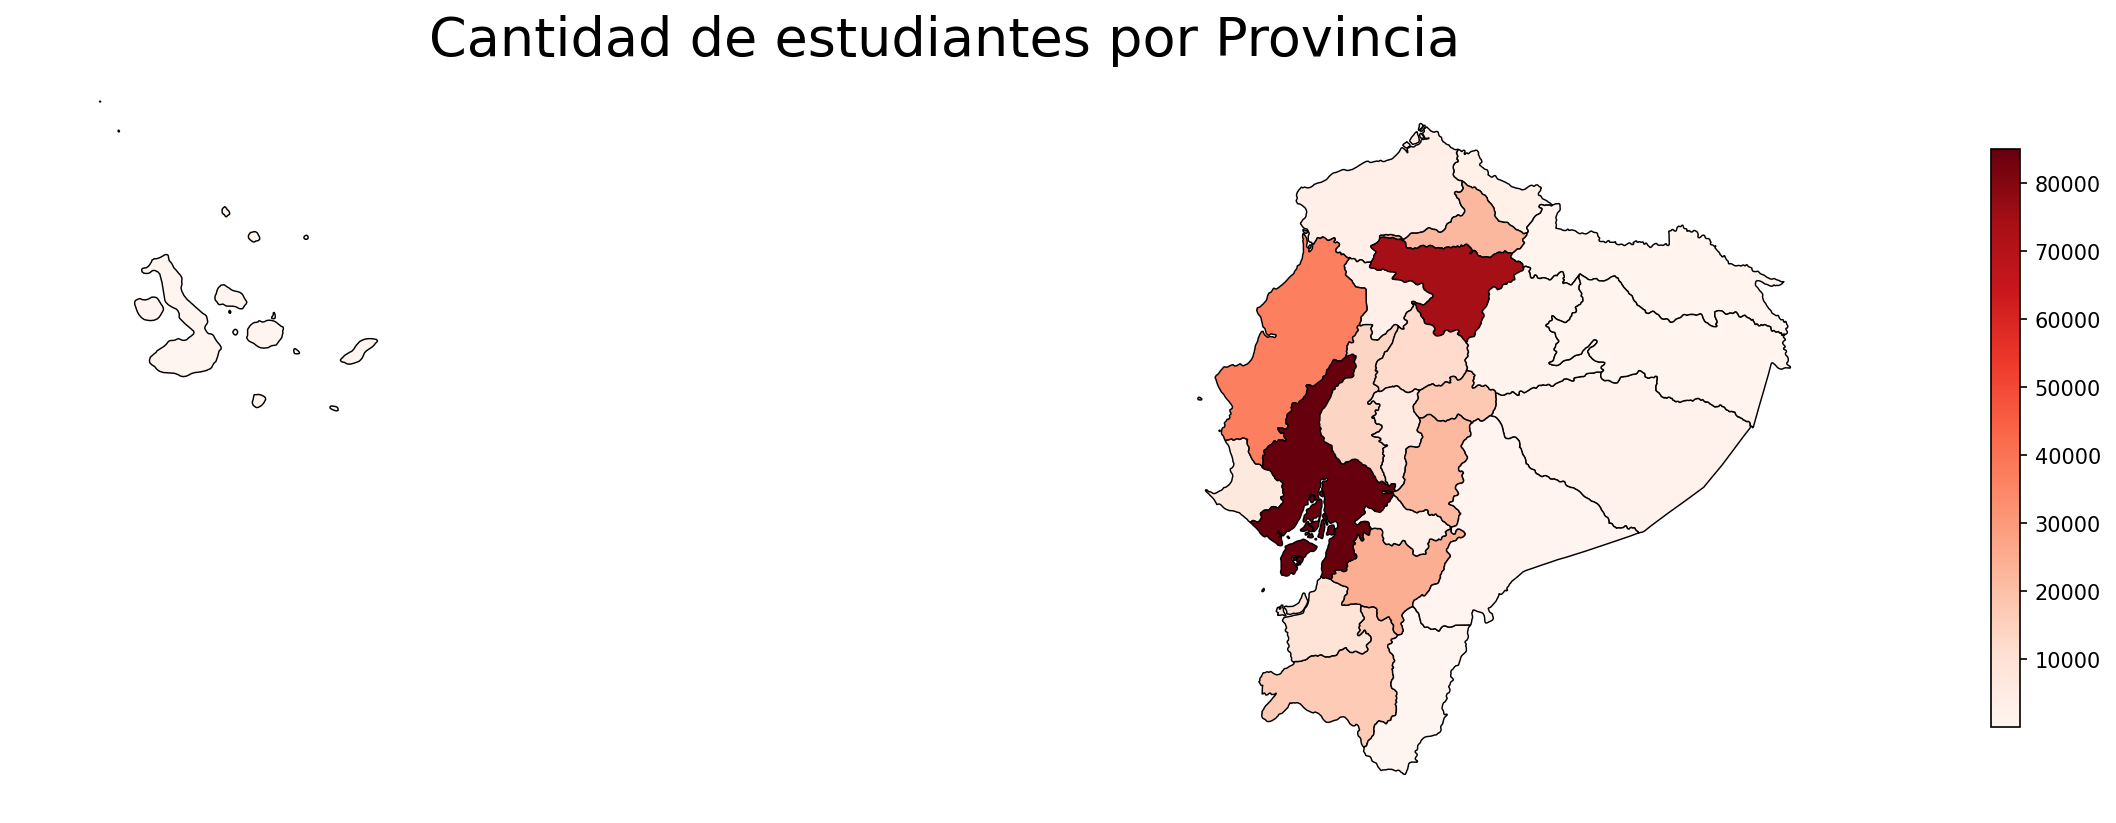

In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Contar estudiantes por provincia (tu DF intacto)
df_counts = df_concatenated.groupby("PROVINCIA")["INS_ID"].nunique().reset_index()
df_counts.columns = ["PROVINCIA", "TOTAL_ESTUDIANTES"]

# 2. Cargar geojson
ecuador = gpd.read_file("geoBoundaries-ECU-ADM1.geojson")

# 3. Normalizar SOLO GeoJSON (sin unidecode)
def normalize(s):
    return (
        s.upper()
         .replace("Á","A").replace("É","E").replace("Í","I").replace("Ó","O").replace("Ú","U")
         .replace("Ü","U")
    )

ecuador["PROV_NORM"] = ecuador["shapeName"].apply(normalize)

# 4. Normalizar tu columna SOLO PARA MATCH (sin modificarla)
df_counts["PROV_NORM"] = df_counts["PROVINCIA"].apply(normalize)

# 5. Merge
ecuador = ecuador.merge(df_counts, on="PROV_NORM", how="left")

# Provincias sin datos → 0
ecuador["TOTAL_ESTUDIANTES"] = ecuador["TOTAL_ESTUDIANTES"].fillna(0)

# 6. Graficar
fig, ax = plt.subplots(figsize=(20, 25), dpi=150)

ecuador.plot(
    column="TOTAL_ESTUDIANTES",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.7,
    ax=ax,
    legend_kwds={'shrink': 0.2}
)

ax.set_title("Cantidad de estudiantes por Provincia", fontsize=26)
ax.axis("off")
plt.show()




In [10]:
print('Información general del DataFrame concatenado:')
df_concatenated.info()

print('\nNúmero de valores nulos por columna (orden descendente):')
print(df_concatenated.isnull().sum().sort_values(ascending=False))

print('\nEstadísticas descriptivas para columnas numéricas:')
print(df_concatenated.describe())

print('\nEstadísticas descriptivas para columnas categóricas:')
print(df_concatenated.describe(include='object'))

Información general del DataFrame concatenado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500036 entries, 0 to 1500035
Data columns (total 44 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   Unnamed: 0               1500036 non-null  int64         
 1   INS_ID                   1500036 non-null  float64       
 2   INI_ID                   1500036 non-null  int64         
 3   PER_ID                   1500036 non-null  int64         
 4   INS_POBLACION            1281921 non-null  object        
 5   INS_TIPO_INSCRIPCION     1500036 non-null  int64         
 6   SEGMENTO_ASPIRANTE       1500036 non-null  object        
 7   CAE_GRUPO                1500036 non-null  object        
 8   CAE_ESTADO               1500036 non-null  int64         
 9   CAE_NOTA_POSTULA         1500036 non-null  int64         
 10  POS_ID                   1500036 non-null  float64       
 11  POS_FECHA_POSTUL

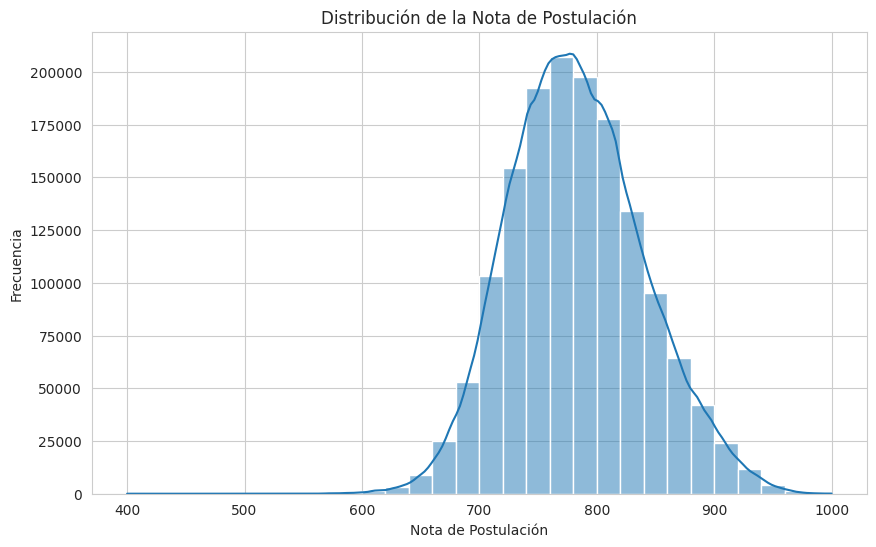

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# Visualization 1: Distribution of CAE_NOTA_POSTULA (Numerical)
plt.figure(figsize=(10, 6))
sns.histplot(df_concatenated['NOTA_POSTULA'].dropna(), kde=True, bins=30)
plt.title('Distribución de la Nota de Postulación')
plt.xlabel('Nota de Postulación')
plt.ylabel('Frecuencia')
plt.show()



/tmp/ipykernel_28975/2626495622.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


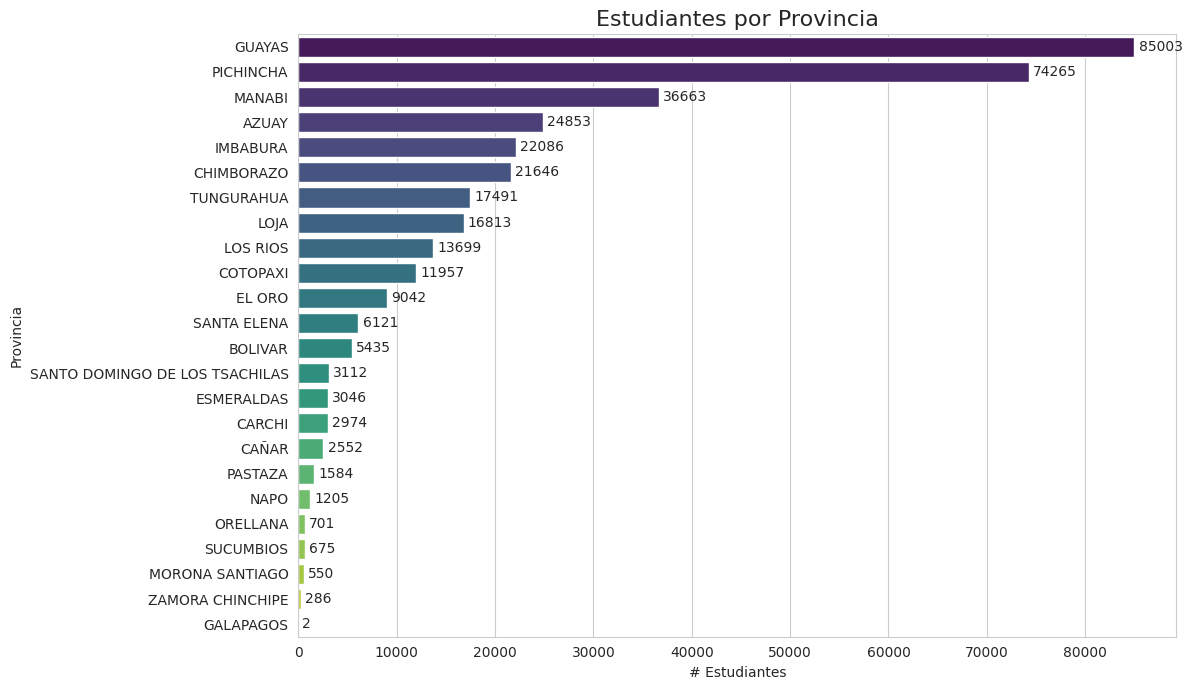

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Agrupar por provincia y contar INS_ID únicos
provincia_unique = (
    df_concatenated.groupby('PROVINCIA')['INS_ID']
    .nunique()
    .reset_index(name='INS_ID_UNICOS')
)

# 2) Ordenar de mayor a menor
provincia_unique = provincia_unique.sort_values('INS_ID_UNICOS', ascending=False)

# 3) Gráfico
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=provincia_unique,
    y='PROVINCIA',
    x='INS_ID_UNICOS',
    palette='viridis'
)

plt.title('Estudiantes por Provincia', fontsize=16)
plt.xlabel('# Estudiantes')
plt.ylabel('Provincia')

# 4) Agregar etiquetas sobre cada barra
for i in ax.containers:
    ax.bar_label(i, fmt='%d', padding=3)  # %d para enteros

plt.tight_layout()
plt.show()


/tmp/ipykernel_28975/531992731.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


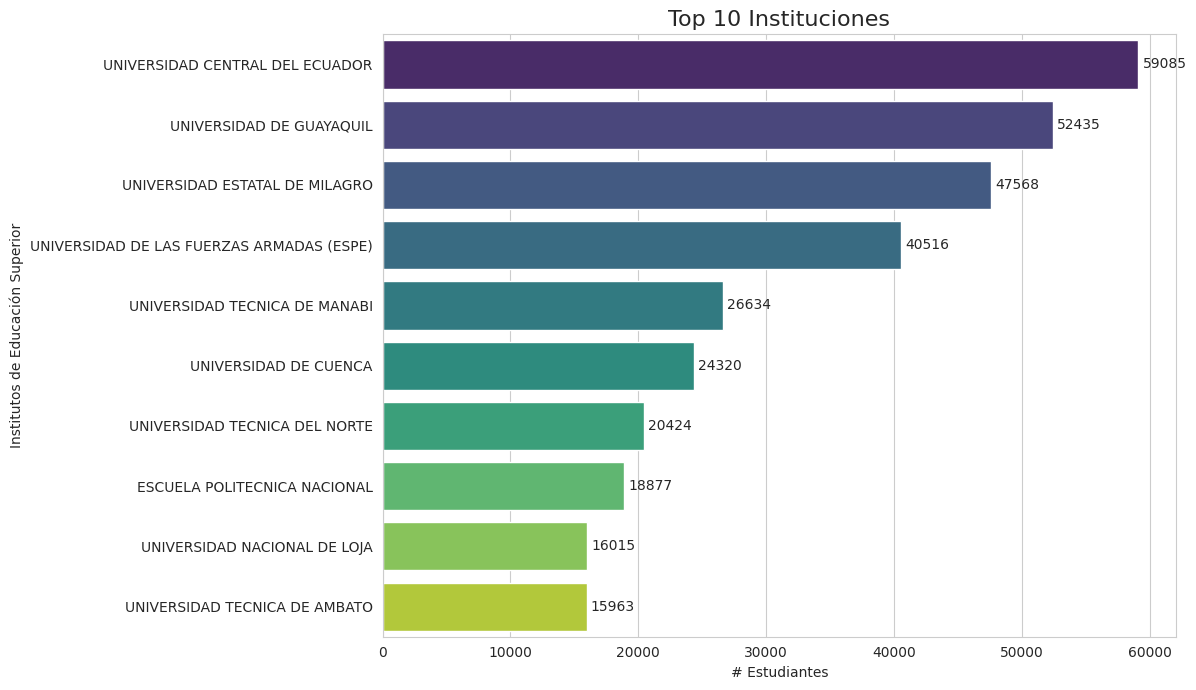

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Agrupar por institución y contar INS_ID únicos
ies_unique = (
    df_concatenated.groupby('IES_NOMBRE_INSTIT')['INS_ID']
    .nunique()
    .reset_index(name='INS_ID_UNICOS')
)

# 2) Ordenar de mayor a menor
ies_unique = ies_unique.sort_values('INS_ID_UNICOS', ascending=False)

# 3) Tomar el TOP 10
ies_top10 = ies_unique.head(10)

# 4) Gráfico
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=ies_top10,
    y='IES_NOMBRE_INSTIT',
    x='INS_ID_UNICOS',
    palette='viridis'
)

plt.title('Top 10 Instituciones', fontsize=16)
plt.xlabel('# Estudiantes')
plt.ylabel('Institutos de Educación Superior')

# 5) Agregar etiquetas sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_28975/3894084487.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


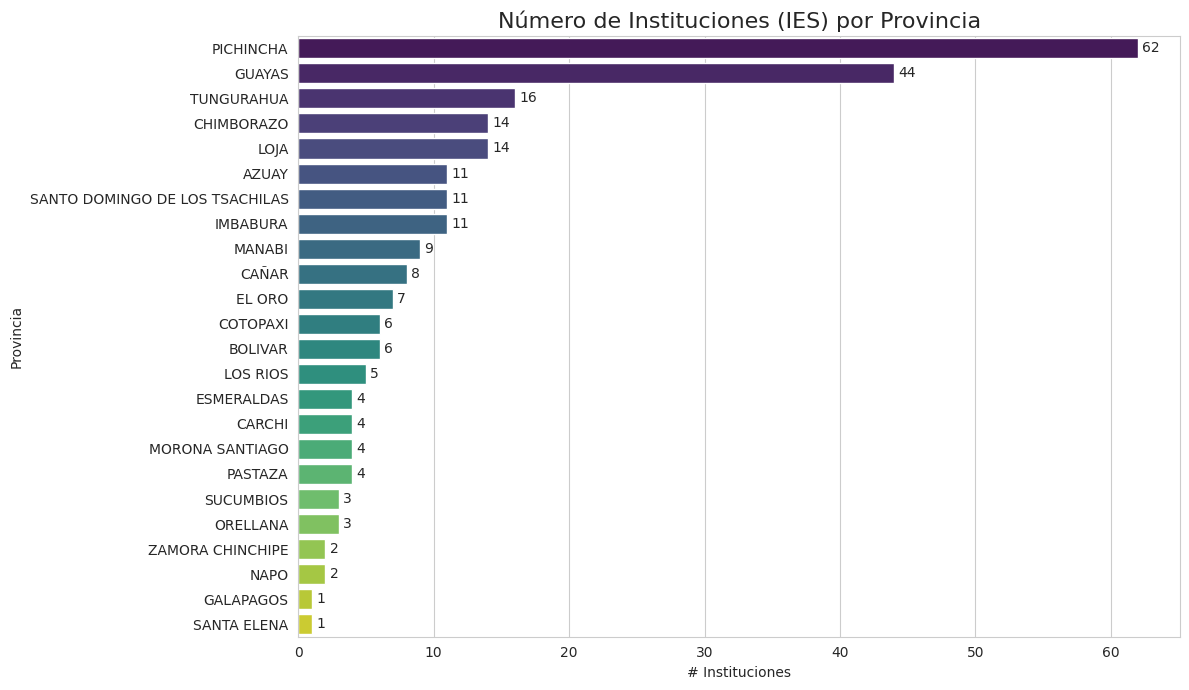

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Agrupar por provincia y contar instituciones únicas
provincia_ies_unique = (
    df_concatenated.groupby('PROVINCIA')['IES_NOMBRE_INSTIT']
    .nunique()
    .reset_index(name='IES_UNICAS')
)

# 2) Ordenar de mayor a menor
provincia_ies_unique = provincia_ies_unique.sort_values('IES_UNICAS', ascending=False)

# 3) Gráfico
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=provincia_ies_unique,
    y='PROVINCIA',
    x='IES_UNICAS',
    palette='viridis'
)

plt.title('Número de Instituciones (IES) por Provincia', fontsize=16)
plt.xlabel('# Instituciones')
plt.ylabel('Provincia')

# 4) Agregar etiquetas sobre cada barra
for cont in ax.containers:
    ax.bar_label(cont, fmt='%d', padding=3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_28975/2138512221.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


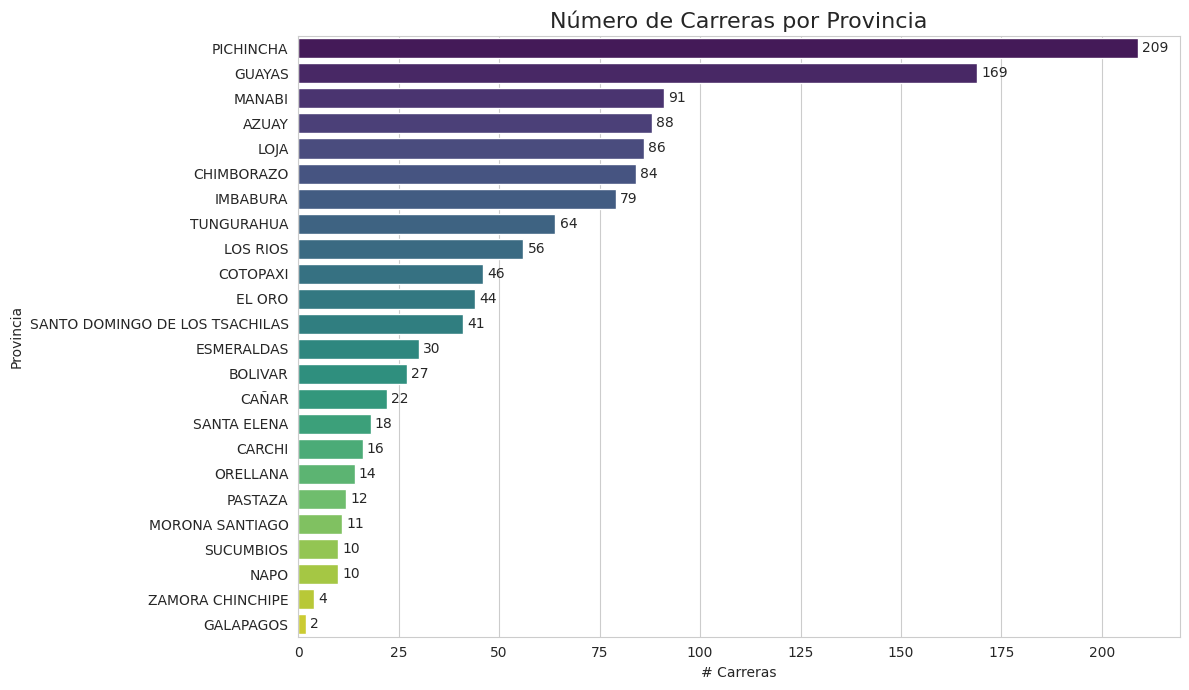

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Agrupar por provincia y contar carreras únicas
provincia_carreras_unique = (
    df_concatenated.groupby('PROVINCIA')['CAR_NOMBRE_CARRERA']
    .nunique()
    .reset_index(name='CARRERAS_UNICAS')
)

# 2) Ordenar de mayor a menor
provincia_carreras_unique = provincia_carreras_unique.sort_values('CARRERAS_UNICAS', ascending=False)

# 3) Gráfico
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=provincia_carreras_unique,
    y='PROVINCIA',
    x='CARRERAS_UNICAS',
    palette='viridis'
)

plt.title('Número de Carreras por Provincia', fontsize=16)
plt.xlabel('# Carreras')
plt.ylabel('Provincia')

# 4) Agregar etiquetas sobre cada barra
for cont in ax.containers:
    ax.bar_label(cont, fmt='%d', padding=3)

plt.tight_layout()
plt.show()


In [16]:
display(df_concatenated[['NOTA_POSTULA']].describe().T)

,count,mean,std,min,25%,50%,75%,max
NOTA_POSTULA,1500036.0,782.593849,57.005316,400.0,742.0,780.0,820.0,1000.0


In [17]:
display(df_concatenated[['IES_NOMBRE_INSTIT']].describe().T)

,count,unique,top,freq
IES_NOMBRE_INSTIT,1500036,218,UNIVERSIDAD DE GUAYAQUIL,246624


In [18]:
display(df_concatenated[['CAR_NOMBRE_CARRERA']].describe().T)

,count,unique,top,freq
CAR_NOMBRE_CARRERA,1500036,352,DERECHO,81749


In [19]:
df_concatenated['INS_ID'].nunique()


218766

In [20]:
df_concatenated["PROVINCIA"].unique()


array(['MANABI', 'LOJA', 'PICHINCHA', 'AZUAY', 'GUAYAS', 'CAÑAR',
       'IMBABURA', 'EL ORO', 'CHIMBORAZO', 'SANTA ELENA',
       'MORONA SANTIAGO', 'LOS RIOS', 'TUNGURAHUA', 'BOLIVAR', 'PASTAZA',
       'CARCHI', 'ZAMORA CHINCHIPE', 'COTOPAXI', 'NAPO', 'ESMERALDAS',
       'SUCUMBIOS', 'SANTO DOMINGO DE LOS TSACHILAS', 'ORELLANA',
       'GALAPAGOS'], dtype=object)

In [21]:
# Calcular provincias distintas por estudiante
prov_por_ins = (
    df_concatenated.groupby('INS_ID')['PROVINCIA']
    .nunique()
    .reset_index(name='PROVINCIAS_DISTINTAS')
)

# Ordenar de mayor a menor
prov_por_ins = prov_por_ins.sort_values('PROVINCIAS_DISTINTAS', ascending=False)

display(prov_por_ins)


,INS_ID,PROVINCIAS_DISTINTAS
151465,11819035.0,11
200516,12032509.0,11
109453,11683296.0,10
4207,11389360.0,10
115236,11701066.0,10
...,...,...
218745,12265940.0,1
218744,12265939.0,1
23,11379384.0,1
20,11379378.0,1


In [22]:
import pandas as pd
#  INS_ID únicos a contar
columna_fecha = 'POS_FECHA_POSTULACION'
columna_id = 'INS_ID'

# 2. Convertir la columna de fecha a tipo datetime de forma temporal o permanente
# Usamos 'format="mixed"' para manejar los diferentes formatos que tienes (con y sin segundos)
df_concatenated['Fecha_dt'] = pd.to_datetime(df_concatenated[columna_fecha], format='mixed', dayfirst=True)

# 3. Extraer el Año y el Mes en nuevas columnas
# Usamos el accesorio .dt para datetime
df_concatenated['Año'] = df_concatenated['Fecha_dt'].dt.year
df_concatenated['Mes'] = df_concatenated['Fecha_dt'].dt.month

# 4. Crear la tabla resumen usando GroupBy y nunique()
# Agrupamos por Año y Mes, y contamos los INS_ID únicos
tabla_resumen = df_concatenated.groupby(['Año', 'Mes'])[columna_id].nunique().reset_index()

# Opcional: Renombrar la columna del conteo para que sea más clara
tabla_resumen = tabla_resumen.rename(columns={columna_id: 'Cantidad Estudiantes'})

# 5. Mostrar la tabla resultante
# Ordenamos por año y mes para una mejor visualización
tabla_resumen = tabla_resumen.sort_values(by=['Año', 'Mes'])
print("Tabla Resumen de Estudiantes únicos por Año y Mes:")
print(tabla_resumen)


Tabla Resumen de Estudiantes únicos por Año y Mes:
    Año  Mes  Cantidad Estudiantes
0  2021    9                169827
1  2021   10                124425


In [23]:
import altair as alt
import pandas as pd

# Agrupar datos por cantón
canton_agg_data = df_concatenated.groupby('CANTON').agg(
    Numero_de_Estudiantes=('INS_ID', 'nunique'),
    Nota_Promedio=('NOTA_POSTULA', 'mean')
).reset_index()

# Ordenar por número de estudiantes
canton_agg_data_sorted = canton_agg_data.sort_values('Numero_de_Estudiantes', ascending=False)

# Calcular altura proporcional, pero no excesiva
n_cantones = len(canton_agg_data_sorted)
altura = max(400, min(25 * n_cantones, 800))  # entre 400 y 800 px según cantidad de cantones

# Barra: número de estudiantes
bars = alt.Chart(canton_agg_data_sorted).mark_bar(color='lightblue').encode(
    y=alt.Y(
        'CANTON',
        sort=alt.EncodingSortField(field='Numero_de_Estudiantes', order='descending'),
        axis=alt.Axis(title='Cantón'),
        scale=alt.Scale(padding=0.25)  # separación moderada entre barras
    ),
    x=alt.X('Numero_de_Estudiantes', title='Número de Estudiantes', axis=alt.Axis(titleColor='blue')),
    tooltip=['CANTON', 'Numero_de_Estudiantes', alt.Tooltip('Nota_Promedio', format='.2f')]
)

# Texto sobre las barras
labels = bars.mark_text(
    align='left',
    baseline='middle',
    dx=3,
    size=11
).encode(
    text='Numero_de_Estudiantes:Q'
)

# Línea: nota promedio en eje X secundario
line = alt.Chart(canton_agg_data_sorted).mark_line(color='red', size=3, point=True).encode(
    y=alt.Y(
        'CANTON',
        sort=alt.EncodingSortField(field='Numero_de_Estudiantes', order='descending'),
        scale=alt.Scale(padding=0.25)
    ),
    x=alt.X('Nota_Promedio', title='Nota Promedio', axis=alt.Axis(titleColor='red', offset=60)),
    tooltip=['CANTON', 'Numero_de_Estudiantes', alt.Tooltip('Nota_Promedio', format='.2f')]
)

# Combinar capas
final_chart = alt.layer(
    bars,
    labels,
    line
).resolve_scale(
    x='independent'
).properties(
    title=alt.TitleParams(
        text='Número de Estudiantes y Nota Promedio por Cantón',
        anchor='start',
        fontSize=16,
        dy=5
    ),
    width=900,
    height=altura
).configure_axis(
    labelFontSize=12,
    titleFontSize=14
).interactive()

final_chart


alt.LayerChart(...)

In [24]:
df_students_courses = df_concatenated[['INS_ID', 'IES_NOMBRE_INSTIT', 'CAR_NOMBRE_CARRERA', 'CANTON', 'PARROQUIA', 'PROVINCIA', 'SUBAREA_NOMBRE', 'JORNADA', 'MODALIDAD', 'NOTA_POSTULA']]

df_students_courses

,INS_ID,IES_NOMBRE_INSTIT,CAR_NOMBRE_CARRERA,CANTON,PARROQUIA,PROVINCIA,SUBAREA_NOMBRE,JORNADA,MODALIDAD,NOTA_POSTULA
0,12263583.0,UNIVERSIDAD TECNICA DE MANABI,DERECHO,PORTOVIEJO,PORTOVIEJO,MANABI,DERECHO,NO APLICA JORNADA,EN LINEA,714
1,12263583.0,UNIVERSIDAD NACIONAL DE LOJA,CONTABILIDAD Y AUDITORIA,LOJA,"LOJA, CABECERA CANTONAL Y CAPITAL PROVINCIAL",LOJA,EDUCACION COMERCIAL Y ADMINISTRACION,NO APLICA JORNADA,DISTANCIA,714
2,12263583.0,UNIVERSIDAD TECNICA DE MANABI,"BIBLIOTECOLOGIA, DOCUMENTACION Y ARCHIVO",PORTOVIEJO,PORTOVIEJO,MANABI,PERIODISMO E INFORMACION,NO APLICA JORNADA,HIBRIDA,714
3,12263583.0,UNIVERSIDAD TECNICA DE MANABI,ADMINISTRACION DE EMPRESAS,PORTOVIEJO,PORTOVIEJO,MANABI,EDUCACION COMERCIAL Y ADMINISTRACION,NO APLICA JORNADA,HIBRIDA,714
4,12263583.0,UNIVERSIDAD TECNICA DE MANABI,EDUCACION INICIAL,PORTOVIEJO,PORTOVIEJO,MANABI,EDUCACION,NO APLICA JORNADA,EN LINEA,714
...,...,...,...,...,...,...,...,...,...,...
1500031,11502106.0,UNIVERSIDAD DE GUAYAQUIL,TURISMO,GUAYAQUIL,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAS,SERVICIOS PERSONALES,NOCTURNA,PRESENCIAL,718
1500032,11502106.0,UNIVERSIDAD DE GUAYAQUIL,INGENIERIA CIVIL,GUAYAQUIL,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAS,ARQUITECTURA Y CONSTRUCCION,MATUTINA,PRESENCIAL,718
1500033,11502106.0,UNIVERSIDAD DE GUAYAQUIL,SISTEMAS DE INFORMACION,GUAYAQUIL,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAS,TECNOLOGIAS DE LA INFORMACION Y LA COMUNICACIO...,VESPERTINA,PRESENCIAL,718
1500034,11502106.0,UNIVERSIDAD DE GUAYAQUIL,PSICOLOGIA,GUAYAQUIL,"GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL",GUAYAS,CIENCIAS SOCIALES Y DEL COMPORTAMIENTO,VESPERTINA,PRESENCIAL,718


In [27]:
# ===== FILTRAR SOLO LO QUE USAREMOS EN SVD =====
# 1. Crear el dataset SVD limpio
df_svd = df_concatenated[['INS_ID', 'IES_NOMBRE_INSTIT', 'CAR_NOMBRE_CARRERA']].dropna()

# Crear ítem SOLO institución + carrera
df_svd['ITEM'] = df_svd['IES_NOMBRE_INSTIT'] + ' - ' + df_svd['CAR_NOMBRE_CARRERA']

# Feedback implícito → 1 = postuló
df_svd['INTERACCION'] = 1

df_svd.head()


,INS_ID,IES_NOMBRE_INSTIT,CAR_NOMBRE_CARRERA,ITEM,INTERACCION
0,12263583.0,UNIVERSIDAD TECNICA DE MANABI,DERECHO,UNIVERSIDAD TECNICA DE MANABI - DERECHO,1
1,12263583.0,UNIVERSIDAD NACIONAL DE LOJA,CONTABILIDAD Y AUDITORIA,UNIVERSIDAD NACIONAL DE LOJA - CONTABILIDAD Y ...,1
2,12263583.0,UNIVERSIDAD TECNICA DE MANABI,"BIBLIOTECOLOGIA, DOCUMENTACION Y ARCHIVO",UNIVERSIDAD TECNICA DE MANABI - BIBLIOTECOLOGI...,1
3,12263583.0,UNIVERSIDAD TECNICA DE MANABI,ADMINISTRACION DE EMPRESAS,UNIVERSIDAD TECNICA DE MANABI - ADMINISTRACION...,1
4,12263583.0,UNIVERSIDAD TECNICA DE MANABI,EDUCACION INICIAL,UNIVERSIDAD TECNICA DE MANABI - EDUCACION INICIAL,1


In [28]:
# 2. Matriz usuario–ítem binaria

user_item_matrix = df_svd.pivot_table(
    index='INS_ID',
    columns='ITEM',
    values='INTERACCION',
    aggfunc='max'
).fillna(0)

user_item_matrix.shape


(218766, 1737)

In [29]:
# 3. Reducir por memoria (muy importante para las pruebas sin mucha RAM)
import numpy as np
from scipy.sparse import csr_matrix

# Tomar 50% de ítems por RAM
subset_cols = np.random.choice(user_item_matrix.columns,
                               size=int(len(user_item_matrix.columns) * 0.50),
                               replace=False)

subset_users = np.random.choice(user_item_matrix.index,
                                size=int(len(user_item_matrix.index) * 0.50),
                                replace=False)

user_item_small = user_item_matrix.loc[subset_users, subset_cols]

interaction_matrix = csr_matrix(user_item_small.values)



In [30]:
print(user_item_small.shape)

(109383, 868)


TRAIN y TEST

In [31]:
#  4. Crea train test 2min

import random

def crear_train_test(user_item_matrix, items_por_test=1):
    train = user_item_matrix.copy()
    test = {}

    for user in train.index:
        items_user = list(train.loc[user][train.loc[user] > 0].index)

        if len(items_user) > items_por_test:
            ocultar = random.sample(items_user, items_por_test)
            test[user] = ocultar
            train.loc[user, ocultar] = 0

    return train, test

train_matrix, test_items = crear_train_test(user_item_small, items_por_test=1)
interaction_train = csr_matrix(train_matrix.values)



In [32]:
total_interacciones = (user_item_small.values > 0).sum()
print("Total de interacciones:", total_interacciones)

train_interacciones = (train_matrix.values > 0).sum()
print("Interacciones en train:", train_interacciones)

test_interacciones = sum(len(v) for v in test_items.values())
print("Interacciones en test:", test_interacciones)


Total de interacciones: 304286
Interacciones en train: 221789
Interacciones en test: 82497


In [33]:
# 5. Entrenar SVD usando solo el TRAIN

from sklearn.decomposition import TruncatedSVD

n_components = 50  # k óptimo
svd = TruncatedSVD(n_components=n_components, random_state=42)

user_features = svd.fit_transform(interaction_train)
item_features = svd.components_

pred_matrix = np.dot(user_features, item_features)

pred_df = pd.DataFrame(
    pred_matrix,
    index=train_matrix.index,
    columns=train_matrix.columns
)


In [34]:
# 6. Generar recall_scores por usuario
# -------------------------------------------------------------------
recall_scores = []
k_rank = 10

for user, ocultos in test_items.items():

    # Solo 1 item oculto (Leave-One-Out)
    item_oculto = ocultos[0]

    # Predicciones del usuario
    user_scores = pred_df.loc[user]

    # Ranking top-k
    ranking = user_scores.sort_values(ascending=False).index[:k_rank]

    # 1 si aparece en top-k, 0 si no
    recall_scores.append(1 if item_oculto in ranking else 0)


Mide en cuántos casos el modelo logra recomendar una opción real del estudiante dentro de sus primeras k recomendaciones.

In [35]:
# 7. Evaluar el modelo usando TEST

def evaluar_test_topk(test_items, pred_df, k=10):
    aciertos = 0
    total = 0

    for user, items_ocultos in test_items.items():
        ranking = pred_df.loc[user].sort_values(ascending=False).index[:k]

        for item in items_ocultos:
            if item in ranking:
                aciertos += 1
            total += 1

    return aciertos / total

recall_loo = evaluar_test_topk(test_items, pred_df, k=10)
print("Recall Leave-One-Out @10:", recall_loo)


Recall Leave-One-Out @10: 0.25929427736766186


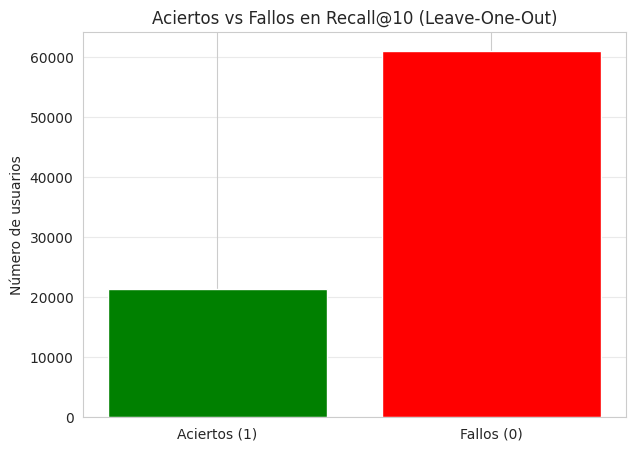

In [36]:
import matplotlib.pyplot as plt
import numpy as np

hits = sum(recall_scores)
misses = len(recall_scores) - hits

plt.figure(figsize=(7,5))
plt.bar(["Aciertos (1)", "Fallos (0)"], [hits, misses], color=["green","red"])
plt.ylabel("Número de usuarios")
plt.title("Aciertos vs Fallos en Recall@10 (Leave-One-Out)")
plt.grid(axis='y', alpha=0.4)
plt.show()


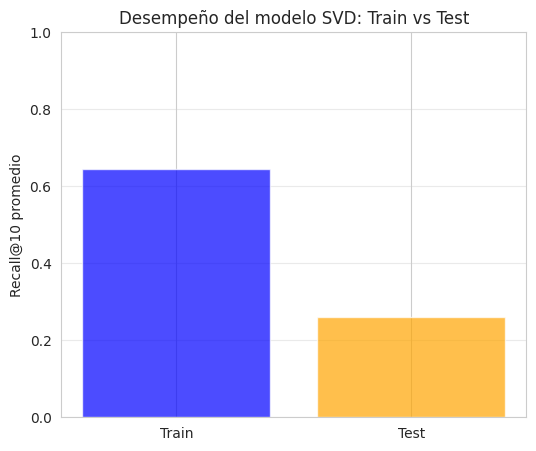

In [37]:
# 8. Recall@10 Train vs Test 2min

recall_test_scores = []
k_rank = 10

for user, ocultos in test_items.items():

    item_oculto = ocultos[0]

    user_scores = pred_df.loc[user]
    ranking = user_scores.sort_values(ascending=False).index[:k_rank]

    recall_test_scores.append(1 if item_oculto in ranking else 0)


recall_train_scores = []

for user in train_matrix.index:
    # Items que el usuario sí tenía en TRAIN
    relevantes = list(train_matrix.loc[user][train_matrix.loc[user] > 0].index)

    if len(relevantes) == 0:
        continue

    user_scores = pred_df.loc[user]
    ranking = user_scores.sort_values(ascending=False).index[:k_rank]

    # ¿Cuántos de los ítems relevantes aparecieron en el top-k?
    hits = sum([1 for item in relevantes if item in ranking])
    recall = hits / len(relevantes)

    recall_train_scores.append(recall)


train_recall = np.mean(recall_train_scores)
test_recall = np.mean(recall_test_scores)

plt.figure(figsize=(6,5))
plt.bar(["Train", "Test"], [train_recall, test_recall],
        color=["blue", "orange"], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("Recall@10 promedio")
plt.title("Desempeño del modelo SVD: Train vs Test")
plt.grid(axis='y', alpha=0.4)
plt.show()


Econtrar k

In [38]:
# 9. Métricas de Ranking (Precision@k, Recall@k, NDCG@k)

from sklearn.metrics import ndcg_score

def precision_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    hits = sum(1 for item in rec_k if item in relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0
    rec_k = recommended[:k]
    hits = sum(1 for item in rec_k if item in relevant)
    return hits / len(relevant)

def ndcg_at_k_scores(user_scores, relevant_items, k):
    top_items = user_scores.sort_values(ascending=False).index[:k]
    top_scores = user_scores.sort_values(ascending=False).values[:k]

    y_true = np.array([[1 if item in relevant_items else 0 for item in top_items]])
    y_score = np.array([top_scores])

    if y_true.sum() == 0:
        return 0

    return ndcg_score(y_true, y_score)


In [40]:
# 10. k values 8 min

from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd

def evaluar_svd_loo(k, interaction_train, train_matrix, test_items, k_rank=10):
    # 1) Entrenar con TRAIN
    svd = TruncatedSVD(n_components=k, random_state=42)
    user_features = svd.fit_transform(interaction_train)
    item_features = svd.components_

    pred_matrix = np.dot(user_features, item_features)
    pred_df = pd.DataFrame(pred_matrix, index=train_matrix.index, columns=train_matrix.columns)

    # 2) Evaluación Leave-One-Out (Recall/Precision/NDCG @k)
    precisiones, recalls, ndcgs = [], [], []

    for user, ocultos in test_items.items():
        relevantes = set(ocultos)  # 1 ítem oculto

        user_scores = pred_df.loc[user].copy()

        # (Recomendado) excluir ítems ya vistos en TRAIN para no “recomendar lo mismo”
        vistos = train_matrix.loc[user][train_matrix.loc[user] > 0].index
        user_scores.loc[vistos] = -np.inf

        ranking = user_scores.sort_values(ascending=False).index.tolist()

        precisiones.append(precision_at_k(ranking, relevantes, k_rank))
        recalls.append(recall_at_k(ranking, relevantes, k_rank))
        ndcgs.append(ndcg_at_k_scores(user_scores, relevantes, k_rank))

    return np.mean(precisiones), np.mean(recalls), np.mean(ndcgs)

k_values = [20, 50, 100, 150]
resultados = []

for k in k_values:
    P, R, N = evaluar_svd_loo(k, interaction_train, train_matrix, test_items, k_rank=10)
    resultados.append([k, P, R, N])


In [41]:
df_resultados = pd.DataFrame(resultados,
                             columns=["k", "Precision@10", "Recall@10", "NDCG@10"])
print(df_resultados)


     k  Precision@10  Recall@10   NDCG@10
0   20      0.033684   0.336836  0.196095
1   50      0.028559   0.285586  0.164497
2  100      0.025480   0.254797  0.155247
3  150      0.020423   0.204226  0.123986


In [42]:
ks = [20, 50, 100, 150]

prec = df_resultados["Precision@10"].values
rec = df_resultados["Recall@10"].values
ndcg = df_resultados["NDCG@10"].values


In [43]:
# 11. Codo
def encontrar_codo_geom(ks, valores):
    ks = np.array(ks)
    valores = np.array(valores)

    # Línea entre primeros y últimos puntos
    p1 = np.array([ks[0], valores[0]])
    p2 = np.array([ks[-1], valores[-1]])

    # Distancia de cada punto a la línea recta p1-p2
    distances = np.abs(np.cross(p2 - p1, np.vstack([ks, valores]).T - p1) / np.linalg.norm(p2 - p1))

    idx_codo = np.argmax(distances)
    return ks[idx_codo]




In [44]:
k_opt_prec = encontrar_codo_geom(ks, prec)
k_opt_rec = encontrar_codo_geom(ks, rec)
k_opt_ndcg = encontrar_codo_geom(ks, ndcg)

print("K óptimo (Precision):", k_opt_prec)
print("K óptimo (Recall):", k_opt_rec)
print("K óptimo (NDCG):", k_opt_ndcg)


K óptimo (Precision): 50
K óptimo (Recall): 50
K óptimo (NDCG): 50


/tmp/ipykernel_28975/1537679274.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(p2 - p1, np.vstack([ks, valores]).T - p1) / np.linalg.norm(p2 - p1))


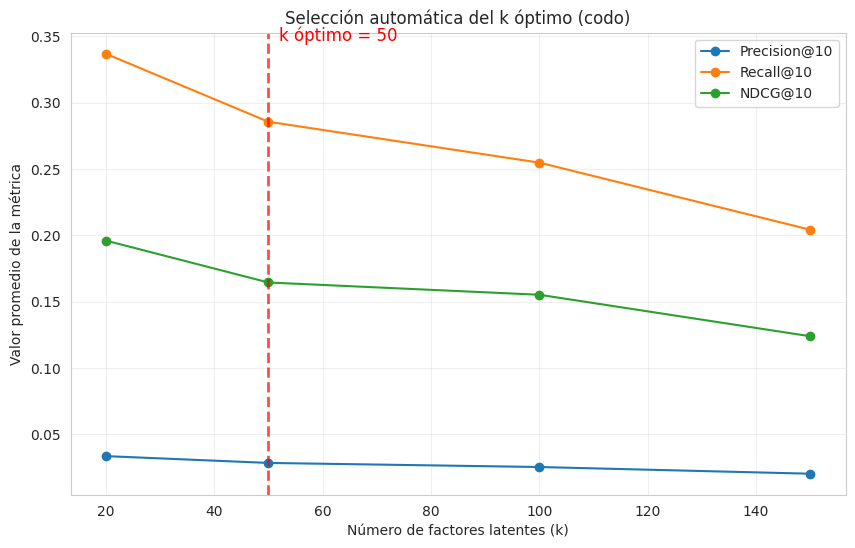

In [45]:
plt.figure(figsize=(10,6))

# Líneas de métricas
plt.plot(ks, prec, marker='o', label="Precision@10")
plt.plot(ks, rec, marker='o', label="Recall@10")
plt.plot(ks, ndcg, marker='o', label="NDCG@10")

# Línea vertical de k óptimo
plt.axvline(x=k_opt_prec, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Texto del k óptimo
plt.text(k_opt_prec + 2, max(max(prec), max(rec), max(ndcg)) + 0.01,
         f"k óptimo = {k_opt_prec}",
         color='red', fontsize=12)

plt.xlabel("Número de factores latentes (k)")
plt.ylabel("Valor promedio de la métrica")
plt.title("Selección automática del k óptimo (codo)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [46]:
# 12. Entrenar SVD Implícito

from sklearn.decomposition import TruncatedSVD

n_components = encontrar_codo_geom(ks, ndcg) #50

svd = TruncatedSVD(n_components=n_components, random_state=42)

user_features = svd.fit_transform(interaction_train)   # 👈 TRAIN
item_features = svd.components_

pred_matrix = np.dot(user_features, item_features)

pred_df = pd.DataFrame(
    pred_matrix,
    index=train_matrix.index,
    columns=train_matrix.columns
)

/tmp/ipykernel_28975/1537679274.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(p2 - p1, np.vstack([ks, valores]).T - p1) / np.linalg.norm(p2 - p1))


In [47]:
# Función de recomendación

def recomendar_usuario(user_id, pred_df, train_matrix, top_k=10):
    pred = pred_df.loc[user_id].sort_values(ascending=False)
    vistos = set(train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index)
    recomendaciones = [i for i in pred.index if i not in vistos]
    return recomendaciones[:top_k]



BASELINE

In [48]:
# ===============================
# BASELINE 1: POPULARIDAD
# ===============================

# Ranking global de ítems por popularidad (usando TRAIN)
popularity_ranking = (
    train_matrix.sum(axis=0)
    .sort_values(ascending=False)
    .index.tolist()
)

def recomendar_popularidad(k=10):
    return popularity_ranking[:k]


In [49]:
# ===============================
# BASELINE 2: ALEATORIO
# ===============================

import numpy as np

all_items = train_matrix.columns.tolist()

def recomendar_aleatorio(k=10, seed=42):
    rng = np.random.default_rng(seed)
    return rng.choice(all_items, size=k, replace=False).tolist()


In [50]:
# ===============================
# EVALUACIÓN BASELINES (LOO)
# ===============================

def evaluar_baseline_recall(test_items, recomendar_fn, k=10):
    hits = 0
    total = 0

    for user, ocultos in test_items.items():
        relevantes = set(ocultos)  # normalmente 1 ítem
        recomendaciones = recomendar_fn(k)

        if any(item in relevantes for item in recomendaciones):
            hits += 1
        total += 1

    return hits / total


In [51]:
recall_pop = evaluar_baseline_recall(test_items, recomendar_popularidad, k=10)
recall_rand = evaluar_baseline_recall(test_items, recomendar_aleatorio, k=10)

print(f"Recall@10 Popularidad: {recall_pop:.4f}")
print(f"Recall@10 Aleatorio:   {recall_rand:.4f}")


Recall@10 Popularidad: 0.1563
Recall@10 Aleatorio:   0.0071


In [52]:
# 7. Evaluación

import random
import numpy as np

usuarios = random.sample(list(test_items.keys()), int(len(test_items)*0.20))

k = 10
precisiones, recalls, ndcgs = [], [], []

for user in usuarios:
    user_scores = pred_df.loc[user].copy()

    # relevantes = ítem oculto (Leave-One-Out)
    relevantes = set(test_items[user])

    # excluir vistos en TRAIN
    vistos = train_matrix.loc[user][train_matrix.loc[user] > 0].index
    user_scores.loc[vistos] = -np.inf

    ranking = user_scores.sort_values(ascending=False).index.tolist()

    precisiones.append(precision_at_k(ranking, relevantes, k))
    recalls.append(recall_at_k(ranking, relevantes, k))
    ndcgs.append(ndcg_at_k_scores(user_scores, relevantes, k))

print("Precision@10 (LOO):", np.mean(precisiones))
print("Recall@10 (LOO):", np.mean(recalls))
print("NDCG@10 (LOO):", np.mean(ndcgs))



Precision@10 (LOO): 0.028225953088065945
Recall@10 (LOO): 0.2822595308806594
NDCG@10 (LOO): 0.1638780472079771


In [53]:
# -----------------------------
# Bootstrap CI (IC 95%)
# -----------------------------

import numpy as np

def bootstrap_ci(values, n_boot=2000, ci=0.95, seed=42):
    """
    values: lista/array con valores por usuario (precision, recall, ndcg, etc.)
    Retorna: (media, ci_low, ci_high)
    """
    rng = np.random.default_rng(seed)
    v = np.asarray(values, dtype=float)
    n = len(v)

    # remuestreo con reemplazo (usuarios)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = v[idx].mean(axis=1)

    alpha = (1 - ci) / 2
    ci_low, ci_high = np.quantile(boot_means, [alpha, 1 - alpha])

    return v.mean(), ci_low, ci_high


# IC para el modelo SVD (lo que ya calculaste en la celda 54)
mean_p, lo_p, hi_p = bootstrap_ci(precisiones, n_boot=2000, ci=0.95, seed=42)
mean_r, lo_r, hi_r = bootstrap_ci(recalls,     n_boot=2000, ci=0.95, seed=42)
mean_n, lo_n, hi_n = bootstrap_ci(ndcgs,       n_boot=2000, ci=0.95, seed=42)

print(f"Precision@10 SVD: {mean_p:.4f}  IC95% [{lo_p:.4f}, {hi_p:.4f}]")
print(f"Recall@10    SVD: {mean_r:.4f}  IC95% [{lo_r:.4f}, {hi_r:.4f}]")
print(f"NDCG@10      SVD: {mean_n:.4f}  IC95% [{lo_n:.4f}, {hi_n:.4f}]")

Precision@10 SVD: 0.0282  IC95% [0.0275, 0.0289]
Recall@10    SVD: 0.2823  IC95% [0.2753, 0.2893]
NDCG@10      SVD: 0.1639  IC95% [0.1591, 0.1686]


In [ ]:

# -----------------------------
# Bootstrap CI para baselines (vector 0/1 por usuario)
# -----------------------------
def baseline_vector(test_items, recomendar_fn, k=10):
    vec = []
    for user, ocultos in test_items.items():
        relevantes = set(ocultos)           # normalmente 1 ítem en LOO
        recomendaciones = recomendar_fn(k)  # lista de items recomendados
        hit = 1.0 if any(item in relevantes for item in recomendaciones) else 0.0
        vec.append(hit)
    return np.asarray(vec, dtype=float)

vec_pop  = baseline_vector(test_items, recomendar_popularidad, k=10)
vec_rand = baseline_vector(test_items, recomendar_aleatorio,   k=10)

mean_pop, lo_pop, hi_pop   = bootstrap_ci(vec_pop,  n_boot=2000, ci=0.95, seed=42)
mean_rand, lo_rand, hi_rand = bootstrap_ci(vec_rand, n_boot=2000, ci=0.95, seed=42)

print(f"Recall@10 Popularidad: {mean_pop:.4f}  IC95% [{lo_pop:.4f}, {hi_pop:.4f}]")
print(f"Recall@10 Aleatorio:   {mean_rand:.4f}  IC95% [{lo_rand:.4f}, {hi_rand:.4f}]")

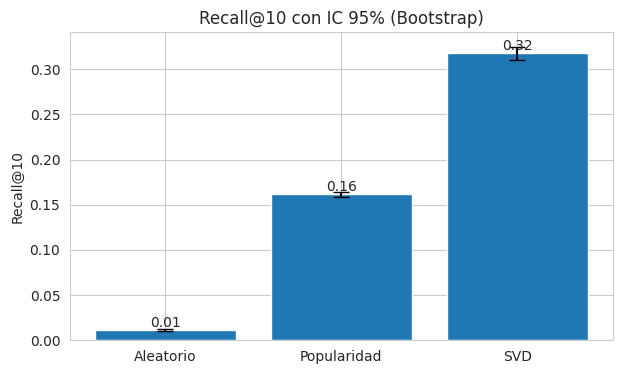

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Aleatorio', 'Popularidad', 'SVD']
means  = [mean_rand, mean_pop, mean_r]

# yerr = distancia desde la media hasta los límites
yerr_lower = [mean_rand - lo_rand, mean_pop - lo_pop, mean_r - lo_r]
yerr_upper = [hi_rand - mean_rand, hi_pop - mean_pop, hi_r - mean_r]
yerr = np.vstack([yerr_lower, yerr_upper])

plt.figure(figsize=(7,4))
plt.bar(labels, means, yerr=yerr, capsize=6)
plt.ylabel('Recall@10')
plt.title('Recall@10 con IC 95% (Bootstrap)')

for i, v in enumerate(means):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()

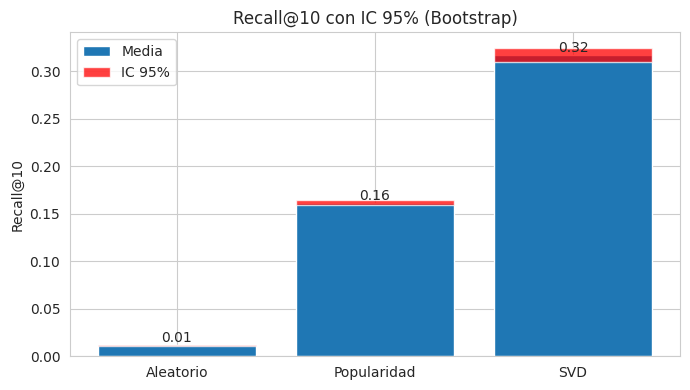

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Aleatorio', 'Popularidad', 'SVD']
means  = np.array([mean_rand, mean_pop, mean_r])
low    = np.array([lo_rand, lo_pop, lo_r])
high   = np.array([hi_rand, hi_pop, hi_r])

x = np.arange(len(labels))
width = 0.8

plt.figure(figsize=(7,4))

# Barras de la media (celeste)
plt.bar(
    x,
    means,
    width=width,
    #color='skyblue',
    label='Media'
)

# Barras del intervalo de confianza (verde transparente)
plt.bar(
    x,
    high - low,      # altura del IC
    bottom=low,      # límite inferior
    width=width,
    color='red',
    alpha=0.75,
    label='IC 95%'
)

plt.xticks(x, labels)
plt.ylabel('Recall@10')
plt.title('Recall@10 con IC 95% (Bootstrap)')
plt.legend()

# Texto con el valor medio
for i, v in enumerate(means):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

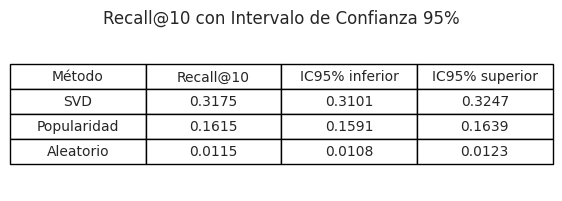

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 2))
ax.axis('off')

table_data = [
    ['SVD', f'{mean_r:.4f}', f'{lo_r:.4f}', f'{hi_r:.4f}'],
    ['Popularidad', f'{mean_pop:.4f}', f'{lo_pop:.4f}', f'{hi_pop:.4f}'],
    ['Aleatorio', f'{mean_rand:.4f}', f'{lo_rand:.4f}', f'{hi_rand:.4f}']
]

columns = ['Método', 'Recall@10', 'IC95% inferior', 'IC95% superior']

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title('Recall@10 con Intervalo de Confianza 95%', pad=10)
plt.show()

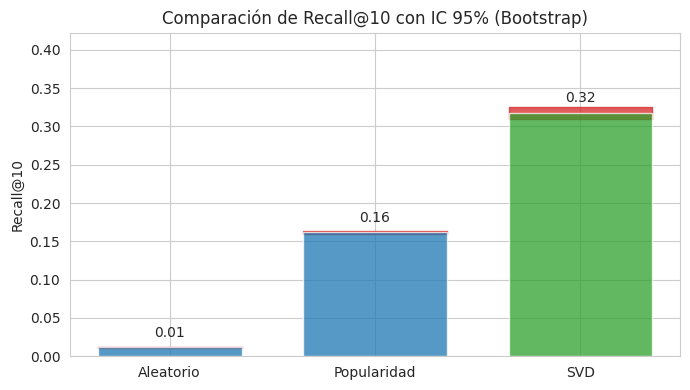

In [ ]:
# ====== Gráfico: Comparación Recall@10 con IC 95% ======

import numpy as np
import matplotlib.pyplot as plt

labels = ['Aleatorio', 'Popularidad', 'SVD']

means = np.array([mean_rand, mean_pop, mean_r])
low   = np.array([lo_rand, lo_pop, lo_r])
high  = np.array([hi_rand, hi_pop, hi_r])

x = np.arange(len(labels))
width = 0.7

# Colores
colors_bar = ['tab:blue', 'tab:blue', 'tab:green']
colors_ic  = ['tab:red', 'tab:red', 'tab:red']

plt.figure(figsize=(7, 4))

# 1️⃣ IC 95% como banda transparente (detrás)
for i in range(len(x)):
    plt.fill_between(
        [x[i] - width/2, x[i] + width/2],
        low[i],
        high[i],
        color=colors_ic[i],
        alpha=0.75
    )

# 2️⃣ Barras de la media
plt.bar(
    x,
    means,
    width=width,
    color=colors_bar,
    alpha=0.75
)

plt.xticks(x, labels)
plt.ylabel('Recall@10')
plt.title('Comparación de Recall@10 con IC 95% (Bootstrap)')

# Escala Y para buena visualización
plt.ylim(0, max(high) * 1.3)

# Texto con valor medio
for i, v in enumerate(means):
    plt.text(i, v + max(high) * 0.03, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

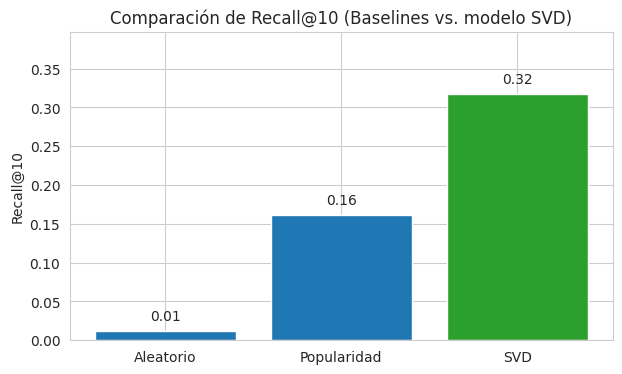

In [ ]:
#BASELINE VS REAL

# ====== Gráfico: Comparación Recall@10 ======

import numpy as np
import matplotlib.pyplot as plt

recall_svd = np.mean(recalls)

labels = ['Aleatorio', 'Popularidad', 'SVD']
values = [recall_rand, recall_pop, recall_svd]

# Colores: baselines azules, SVD verde
colors = ['tab:blue', 'tab:blue', 'tab:green']

plt.figure(figsize=(7, 4))
plt.bar(labels, values, color=colors)
plt.ylabel('Recall@10')
plt.title('Comparación de Recall@10 (Baselines vs. modelo SVD)')

ymax = max(values)
plt.ylim(0, ymax * 1.25)

for i, v in enumerate(values):
    plt.text(i, v + ymax * 0.03, f"{v:.2f}", ha='center', va='bottom')

plt.show()


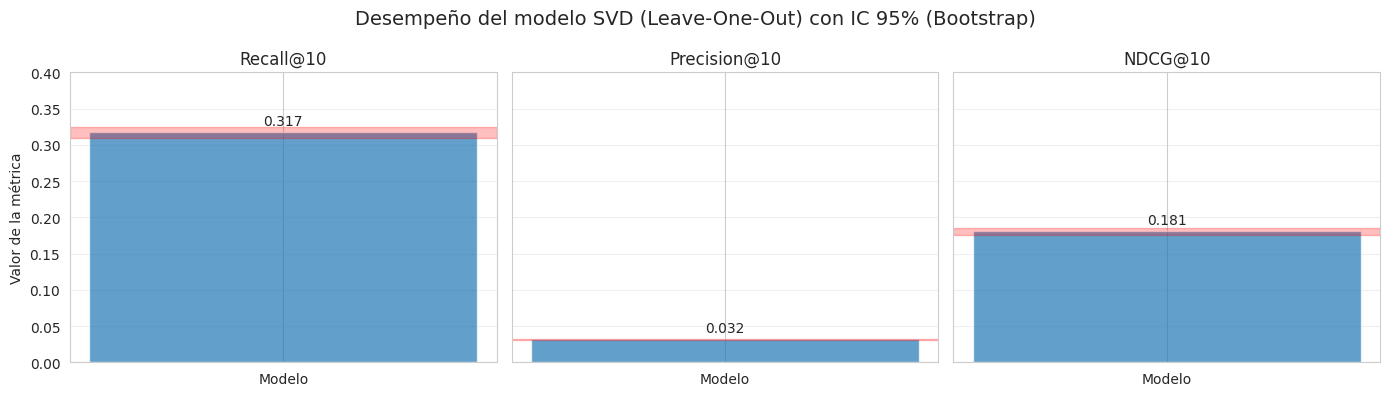

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =============================
# Valores reales + IC (bootstrap)
# =============================
recall_val = mean_r
precision_val = mean_p
ndcg_val = mean_n

# =============================
# Figura
# =============================
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# -----------------------------
# 1) Recall@10
# -----------------------------
axes[0].bar([1], [recall_val], alpha=0.7)
axes[0].axhspan(lo_r, hi_r,color='red', alpha=0.25)
axes[0].set_title("Recall@10")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["Modelo"])
axes[0].set_ylim(0, 0.4)
axes[0].set_ylabel("Valor de la métrica")
axes[0].text(1, recall_val + 0.01, f"{recall_val:.3f}", ha='center')

# -----------------------------
# 2) Precision@10
# -----------------------------
axes[1].bar([1], [precision_val], alpha=0.7)
axes[1].axhspan(lo_p, hi_p,color='red', alpha=0.25)
axes[1].set_title("Precision@10")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Modelo"])
axes[1].set_ylim(0, 0.4)
axes[1].text(1, precision_val + 0.01, f"{precision_val:.3f}", ha='center')

# -----------------------------
# 3) NDCG@10
# -----------------------------
axes[2].bar([1], [ndcg_val], alpha=0.7)
axes[2].axhspan(lo_n, hi_n,color='red', alpha=0.25)
axes[2].set_title("NDCG@10")
axes[2].set_xticks([1])
axes[2].set_xticklabels(["Modelo"])
axes[2].set_ylim(0, 0.4)
axes[2].text(1, ndcg_val + 0.01, f"{ndcg_val:.3f}", ha='center')

# -----------------------------
# Ajustes generales
# -----------------------------
for ax in axes:
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    "Desempeño del modelo SVD (Leave-One-Out) con IC 95% (Bootstrap)",
    fontsize=14
)

plt.tight_layout()
plt.show()

hasta aquí cambie LOO

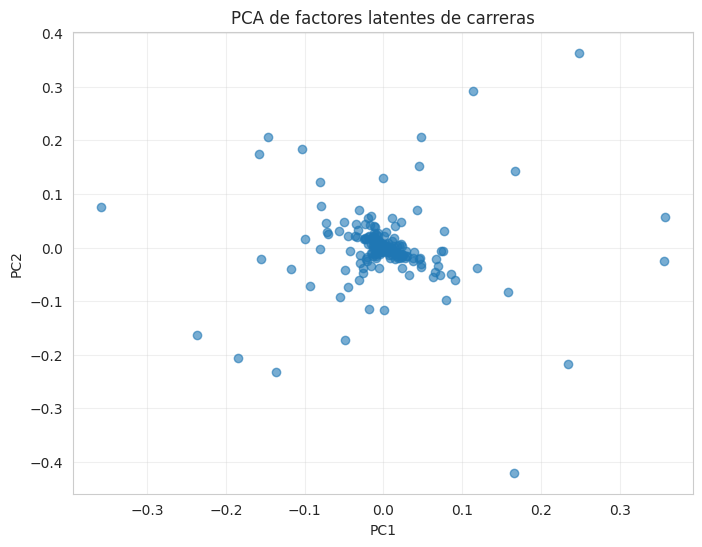

In [ ]:
#Reducir factores latentes de ITEMS (carreras) usando PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Tomamos los factores latentes de ítems (carreras)
item_latents = item_features.T  # (num_items × k)

pca = PCA(n_components=2)
item_pca = pca.fit_transform(item_latents)

plt.figure(figsize=(8,6))
plt.scatter(item_pca[:,0], item_pca[:,1], alpha=0.6)
plt.title("PCA de factores latentes de carreras")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


La nube densa en el centro indica que:

La mayoría de las carreras tienen factores latentes parecidos

No hay carreras extremadamente distintas en términos de patrones de postulación

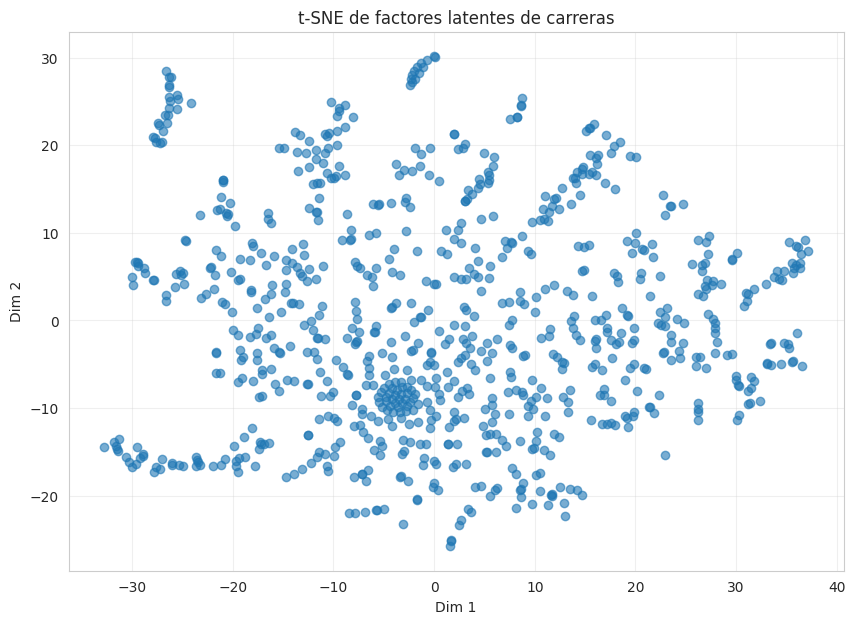

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42)
item_tsne = tsne.fit_transform(item_latents)

plt.figure(figsize=(10,7))
plt.scatter(item_tsne[:,0], item_tsne[:,1], alpha=0.6)
plt.title("t-SNE de factores latentes de carreras")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(alpha=0.3)
plt.show()


🔹 El modelo SVD sí está capturando estructura latente real

No es ruido: se ven agrupaciones claras.

🔹 Hay carreras con perfiles extremadamente distintos

(separadas muy lejos).

🔹 También hay un “núcleo” grande → carreras generalistas.
🔹 Esto es evidencia de que el modelo está encontrando patrones de postulación incluso sin usar demografía.

/tmp/ipykernel_603/1806198475.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


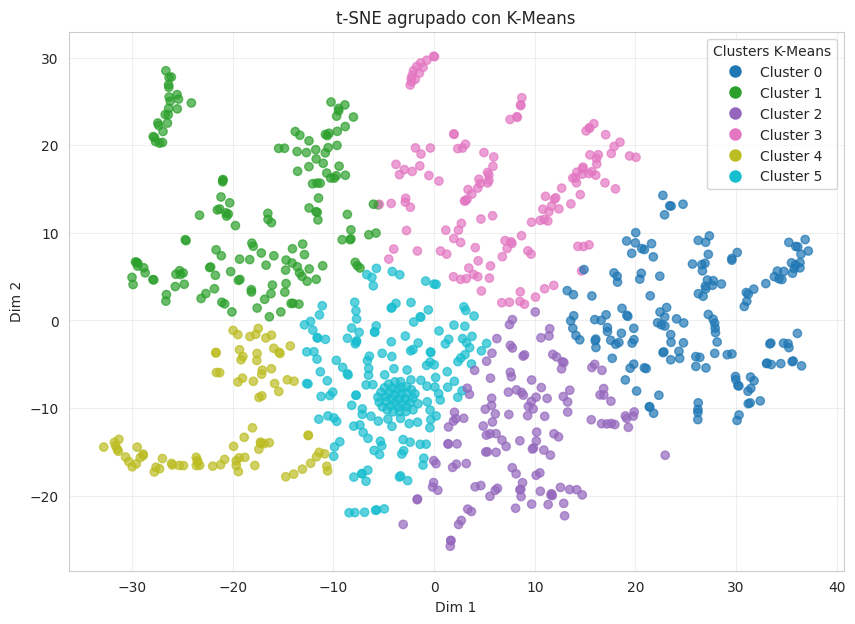

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D

# KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(item_tsne)

# Scatter
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    item_tsne[:,0],
    item_tsne[:,1],
    c=labels,
    cmap="tab10",
    alpha=0.7
)

# ===== CREAR LEYENDA MANUAL =====
unique_labels = np.unique(labels)
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'Cluster {label}',
        markerfacecolor=cmap(label),
        markersize=10
    )
    for label in unique_labels
]

plt.legend(
    handles=legend_elements,
    title="Clusters K-Means",
    loc="best"
)

# Estética
plt.title("t-SNE agrupado con K-Means")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(alpha=0.3)

plt.show()


In [ ]:
clusters = pd.DataFrame({
    "ITEM": user_item_small.columns.tolist(),
    "cluster": labels
})

clusters.head()


,ITEM,cluster
0,UNIVERSIDAD TECNICA DE AMBATO - PSICOLOGIA CLI...,0
1,INSTITUTO TECNOLÓGICO SUPERIOR SIMÓN BOLÍVAR -...,1
2,UNIVERSIDAD LAICA ELOY ALFARO DE MANABI - PSIC...,1
3,UNIVERSIDAD DE CUENCA - INGENIERIA INDUSTRIAL,4
4,INSTITUTO SUPERIOR TECNOLOGICO DEL AZUAY - TEC...,4


In [ ]:
assert len(user_item_small.columns) == len(labels)


In [ ]:
clusters["INSTITUCION"] = clusters["ITEM"].apply(
    lambda x: x.split(" - ", 1)[0]
)

clusters["CARRERA"] = clusters["ITEM"].apply(
    lambda x: x.split(" - ", 1)[1] if " - " in x else x
)


In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)


In [ ]:
# Distancia al centro del cluster (en t-SNE)
from numpy.linalg import norm

clusters["dist_centro"] = 0.0

for c in clusters.cluster.unique():
    idx = clusters.cluster == c
    centro = item_tsne[idx.values].mean(axis=0)
    clusters.loc[idx, "dist_centro"] = norm(item_tsne[idx.values] - centro, axis=1)

# Mostrar las 10 más cercanas al centro
for c in sorted(clusters.cluster.unique()):
    print(f"\nCLUSTER {c}")
    display(
        clusters[clusters.cluster == c]
        .sort_values("dist_centro")
        [["INSTITUCION","CARRERA"]]
        .head(10)
    )



CLUSTER 0


,INSTITUCION,CARRERA
491,UNIVERSIDAD TECNICA DE COTOPAXI,DISEÑO GRAFICO
217,ESCUELA SUPERIOR POLITECNICA DE CHIMBORAZO,AGRONOMIA
803,ESCUELA SUPERIOR POLITECNICA DE CHIMBORAZO,TURISMO
601,UNIVERSIDAD TECNICA DE COTOPAXI,INGENIERIA AMBIENTAL
189,UNIVERSIDAD TECNICA DE COTOPAXI,AGRONOMIA
716,UNIVERSIDAD TECNICA DE COTOPAXI,AGROINDUSTRIA
143,ESCUELA SUPERIOR POLITECNICA DE CHIMBORAZO,INGENIERIA AMBIENTAL
79,ESCUELA SUPERIOR POLITECNICA DE CHIMBORAZO,ZOOTECNIA
761,UNIVERSIDAD DE LAS FUERZAS ARMADAS (ESPE),PETROQUIMICA
581,UNIVERSIDAD NACIONAL DE CHIMBORAZO,INGENIERIA INDUSTRIAL



CLUSTER 1


,INSTITUCION,CARRERA
368,UNIVERSIDAD DE GUAYAQUIL,DERECHO
369,UNIVERSIDAD DE GUAYAQUIL,SOCIOLOGIA
647,UNIVERSIDAD ESTATAL DE MILAGRO,PSICOLOGIA
523,UNIVERSIDAD DE GUAYAQUIL,INGENIERIA CIVIL
541,UNIVERSIDAD DE GUAYAQUIL,INGENIERIA AMBIENTAL
550,UNIVERSIDAD DE GUAYAQUIL,BIOLOGIA
58,UNIVERSIDAD ESTATAL DE MILAGRO,INGENIERIA INDUSTRIAL
434,UNIVERSIDAD AGRARIA DEL ECUADOR,MEDICINA VETERINARIA
125,UNIVERSIDAD AGRARIA DEL ECUADOR,ECONOMIA
104,ESCUELA SUPERIOR POLITECNICA DEL LITORAL,INGENIERIA CIVIL



CLUSTER 2


...

,INSTITUCION,CARRERA
349,UNIVERSIDAD TECNICA DE MACHALA,ECONOMIA
614,UNIVERSIDAD TECNICA DE MACHALA,COMERCIO EXTERIOR
168,UNIVERSIDAD TECNICA DE MACHALA,PEDAGOGIA DE LAS CIENCIAS EXPERIMENTALES
659,UNIVERSIDAD TECNICA DE MACHALA,ALIMENTOS
474,UNIVERSIDAD TECNICA DE MACHALA,ACUICULTURA
799,UNIVERSIDAD TECNICA DE MACHALA,PEDAGOGIA DE LA ACTIVIDAD FISICA Y DEPORTE
322,UNIVERSIDAD TECNICA DE MACHALA,PSICOPEDAGOGIA
543,UNIVERSIDAD TECNICA DE MACHALA,TRABAJO SOCIAL
64,UNIVERSIDAD TECNICA DE MACHALA,INGENIERIA QUIMICA
282,UNIVERSIDAD ESTATAL DE MILAGRO,PEDAGOGIA DE LOS IDIOMAS NACIONALES Y EXTRANJEROS



CLUSTER 4


,INSTITUCION,CARRERA
528,UNIVERSIDAD CATOLICA DE CUENCA,BIOQUIMICA Y FARMACIA
780,INSTITUTO TECNOLÓGICO SUPERIOR SAN ISIDRO,TECNICO SUPERIOR EN ENFERMERIA
432,UNIVERSIDAD CATOLICA DE CUENCA,ODONTOLOGIA
245,INSTITUTO TECNOLÓGICO SUPERIOR INTEGRACIÓN ANDINA,TECNOLOGIA SUPERIOR EN ADMINISTRACION
443,UNIVERSIDAD CATOLICA DE CUENCA,INGENIERIA INDUSTRIAL
816,INSTITUTO TECNOLÓGICO SUPERIOR ALMIRANTE ILLINGWORTH,TECNOLOGIA SUPERIOR EN MARKETING DIGITAL Y COMERCIO ELECTRONICO
418,UNIVERSIDAD POLITECNICA SALESIANA,MECANICA
525,INSTITUTO TECNOLÓGICO SUPERIOR LUIS ROGERIO GONZALEZ,TECNOLOGIA SUPERIOR EN MECANICA AUTOMOTRIZ
281,UNIVERSIDAD CATOLICA DE CUENCA,MARKETING E INTELIGENCIA DE MERCADOS
644,INSTITUTO SUPERIOR TECNOLOGICO TECNIEMPRESARIAL WISSEN,TECNOLOGIA SUPERIOR EN ADMINISTRACION



CLUSTER 5


,INSTITUCION,CARRERA
514,PONTIFICIA UNIVERSIDAD CATOLICA DEL ECUADOR,ALIMENTOS
557,PONTIFICIA UNIVERSIDAD CATOLICA DEL ECUADOR,TURISMO
314,INSTITUTO TECNOLÓGICO SUPERIOR SUDAMERICANO,TECNOLOGIA SUPERIOR EN DESARROLLO AMBIENTAL
252,INSTITUTO TECNOLOGICO SUPERIOR NEW GENERATION,TECNOLOGIA SUPERIOR EN TRIBUTACION
530,UNIVERSIDAD REGIONAL AUTONOMA DE LOS ANDES,TECNOLOGIA SUPERIOR EN MECANICA DENTAL
120,PONTIFICIA UNIVERSIDAD CATOLICA DEL ECUADOR,HIDRAULICA
849,INSTITUTO TECNOLÓGICO SUPERIOR CRECERMAS,TECNOLOGIA SUPERIOR EN AGROFORESTERIA
365,UNIVERSIDAD INTERNACIONAL DEL ECUADOR,TURISMO
556,INSTITUTO TECNOLÓGICO SUPERIOR ECUATORIANO DE PRODUCTIVIDAD,ASISTENCIA EN EDUCACION INCLUSIVA CON NIVEL EQUIVALENTE A TECNOLOGIA SUPERIOR
188,INSTITUTO TECNOLÓGICO SUPERIOR JOSÉ ORTEGA Y GASSET,COMUNICACION DIGITAL CON NIVEL EQUIVALENTE A TECNOLOGIA SUPERIOR


In [ ]:
for c in sorted(clusters.cluster.unique()):
    print(f"\n====================")
    print(f"CLUSTER {c}")
    print("====================")
    display(clusters[clusters.cluster == c][["INSTITUCION","CARRERA"]].head(10))



CLUSTER 0


,INSTITUCION,CARRERA
0,UNIVERSIDAD TECNICA DE AMBATO,PSICOLOGIA CLINICA
12,ESCUELA SUPERIOR POLITECNICA DE CHIMBORAZO,INGENIERIA QUIMICA
21,UNIVERSIDAD CENTRAL DEL ECUADOR,COMUNICACION
25,UNIVERSIDAD DE LAS FUERZAS ARMADAS (ESPE),SOFTWARE
43,ESCUELA SUPERIOR POLITECNICA DE CHIMBORAZO,NUTRICION Y DIETETICA
48,INSTITUTO TECNOLÓGICO SUPERIOR VICENTE LEÓN,TECNOLOGIA SUPERIOR EN MARKETING
54,UNIVERSIDAD CENTRAL DEL ECUADOR,SOCIOLOGIA
69,UNIVERSIDAD CENTRAL DEL ECUADOR,PETROLEOS
71,UNIVERSIDAD ESTATAL DE BOLIVAR,PEDAGOGIA DE LAS CIENCIAS EXPERIMENTALES
73,INSTITUTO TECNOLÓGICO SUPERIOR SUCRE,TECNOLOGIA SUPERIOR EN DESARROLLO DE SOFTWARE



CLUSTER 1


,INSTITUCION,CARRERA
1,INSTITUTO TECNOLÓGICO SUPERIOR SIMÓN BOLÍVAR,TECNOLOGIA SUPERIOR EN LOGISTICA PORTUARIA
2,UNIVERSIDAD LAICA ELOY ALFARO DE MANABI,PSICOLOGIA
5,UNIVERSIDAD TECNICA DE MANABI,TECNOLOGIAS DE LA INFORMACION
6,UNIVERSIDAD TECNICA ESTATAL DE QUEVEDO,ADMINISTRACION DE EMPRESAS
8,UNIVERSIDAD LAICA ELOY ALFARO DE MANABI,PEDAGOGIA DE LA LENGUA Y LA LITERATURA
9,UNIVERSIDAD TECNICA ESTATAL DE QUEVEDO,PSICOPEDAGOGIA
13,UNIVERSIDAD PARTICULAR DE ESPECIALIDADES ESPIRITU SANTO,ADMINISTRACION DE EMPRESAS
17,INSTITUTO TECNOLÓGICO SUPERIOR SUDAMERICANO,TECNOLOGIA SUPERIOR EN COMERCIO EXTERIOR
20,INSTITUTO TECNOLÓGICO SUPERIOR DE ARTES DEL ECUADOR,TECNOLOGIA EN SONIDO Y ACUSTICA
31,ESCUELA SUPERIOR POLITECNICA DEL LITORAL,ARQUEOLOGIA



CLUSTER 2


...

,INSTITUCION,CARRERA
7,UNIVERSIDAD DE GUAYAQUIL,TERAPIA OCUPACIONAL
11,UNIVERSIDAD TECNICA DEL NORTE,MEDICINA
22,ESCUELA SUPERIOR POLITECNICA AGROPECUARIA DE MANABI,MEDICINA VETERINARIA
23,UNIVERSIDAD TECNICA DEL NORTE,NUTRICION Y DIETETICA
24,UNIVERSIDAD TECNICA DEL NORTE,TURISMO
26,INSTITUTO TECNOLÓGICO SUPERIOR 17 DE JULIO,TECNOLOGIA SUPERIOR EN QUIMICA
29,UNIVERSIDAD DE GUAYAQUIL,PEDAGOGIA DE LA LENGUA Y LA LITERATURA
50,INSTITUTO TECNOLÓGICO SUPERIOR EL ORO,TECNOLOGIA SUPERIOR EN ELECTRONICA
57,INSTITUTO TECNOLÓGICO SUPERIOR 17 DE JULIO,TECNOLOGIA SUPERIOR EN AUTOMATIZACION E INSTRUMENTACION
59,UNIVERSIDAD ESTATAL PENINSULA DE SANTA ELENA,PETROLEOS



CLUSTER 4


,INSTITUCION,CARRERA
3,UNIVERSIDAD DE CUENCA,INGENIERIA INDUSTRIAL
4,INSTITUTO SUPERIOR TECNOLOGICO DEL AZUAY,TECNOLOGIA SUPERIOR EN CIBERSEGURIDAD
14,UNIVERSIDAD CATOLICA DE CUENCA,DERECHO
19,UNIVERSIDAD DE CUENCA,ADMINISTRACION DE EMPRESAS
28,UNIVERSIDAD NACIONAL DE EDUCACION UNAE,EDUCACION ESPECIAL
42,UNIVERSIDAD CATOLICA DE SANTIAGO DE GUAYAQUIL,DERECHO
52,UNIVERSIDAD NACIONAL DE EDUCACION UNAE,EDUCACION EN CIENCIAS EXPERIMENTALES
60,UNIVERSIDAD CATOLICA DE CUENCA,INGENIERIA CIVIL
63,UNIVERSIDAD DE CUENCA,ECONOMIA
127,INSTITUTO TECNOLÓGICO SUPERIOR BABAHOYO,TECNOLOGIA SUPERIOR EN ADMINISTRACION



CLUSTER 5


,INSTITUCION,CARRERA
10,INSTITUTO SUPERIOR TECNOLÓGICO TSA´CHILA,TECNOLOGIA SUPERIOR EN CONFECCION TEXTIL
15,INSTITUTO TECNOLÓGICO SUPERIOR JUAN MONTALVO,TECNOLOGIA SUPERIOR EN AGROECOLOGIA
18,UNIVERSIDAD TECNICA PARTICULAR DE LOJA,ARTES VISUALES
34,INSTITUTO SUPERIOR TECNOLÓGICO INTERNACIONAL ITI,TECNOLOGIA SUPERIOR EN TURISMO
35,UNIVERSIDAD DE LAS ARTES,PRODUCCION MUSICAL
38,UNIVERSIDAD CATOLICA DE SANTIAGO DE GUAYAQUIL,NEGOCIOS INTERNACIONALES
41,INSTITUTO TECNOLÓGICO SUPERIOR LIBERTAD,TECNOLOGIA SUPERIOR EN TRIBUTACION
44,INSTITUTO TECNOLÓGICO SUPERIOR UNIVERSITEC,TECNOLOGIA SUPERIOR EN TURISMO
47,INSTITUTO TECNOLÓGICO SUPERIOR SAN PABLO DE ATENAS,TECNOLOGIA SUPERIOR EN CONTABILIDAD
51,INSTITUTO TECNOLÓGICO SUPERIOR UNIVERSITEC,TECNOLOGIA SUPERIOR EN ADMINISTRACION HOTELERA


In [ ]:
# Seleccionar estudiante aleatorio
student = random.choice(list(user_item_small.index))
print("Estudiante:", student)

# Obtener recomendaciones
recoms = recomendar_usuario(student, pred_df, user_item_small, 10)

# Crear DataFrame de recomendaciones
df_recoms = pd.DataFrame({
    "Rank": range(1, len(recoms)+1),
    "Recomendación": recoms
})

# Mostrar como tabla ancha estilizada
df_recoms.style.set_table_styles([
    {"selector": "table", "props": [("width", "100%")]},
    {"selector": "th", "props": [("text-align", "center"), ("font-size", "14px")]},
    {"selector": "td", "props": [("text-align", "left"), ("font-size", "13px")]}
])



Estudiante: 11641516.0


,Rank,Recomendación
0,1,UNIVERSIDAD TECNICA DE AMBATO - DERECHO
1,2,UNIVERSIDAD TECNICA DE AMBATO - NUTRICION Y DIETETICA
2,3,UNIVERSIDAD TECNICA DE AMBATO - MEDICINA VETERINARIA
3,4,UNIVERSIDAD TECNICA DE AMBATO - ENFERMERIA
4,5,UNIVERSIDAD TECNICA DEL NORTE - ENFERMERIA
5,6,UNIVERSIDAD TECNICA DEL NORTE - COMUNICACION
6,7,UNIVERSIDAD TECNICA DE AMBATO - ADMINISTRACION DE EMPRESAS
7,8,UNIVERSIDAD TECNICA DE MANABI - ECONOMIA
8,9,UNIVERSIDAD TECNICA DEL NORTE - EDUCACION INICIAL
9,10,UNIVERSIDAD TECNICA DE AMBATO - EDUCACION BASICA


In [ ]:
df_real_student = df_students_courses[df_students_courses['INS_ID'] == student]

df_real_student_table = df_real_student[[
    'INS_ID',
    'IES_NOMBRE_INSTIT',
    'CAR_NOMBRE_CARRERA',
    'CANTON',
    'PARROQUIA',
    'PROVINCIA',
    'SUBAREA_NOMBRE',
    'JORNADA',
    'MODALIDAD',
    'NOTA_POSTULA'
]]

print("\n🟢 Información real del estudiante en los datos:\n")
display(df_real_student_table)



🟢 Información real del estudiante en los datos:



,INS_ID,IES_NOMBRE_INSTIT,CAR_NOMBRE_CARRERA,CANTON,PARROQUIA,PROVINCIA,SUBAREA_NOMBRE,JORNADA,MODALIDAD,NOTA_POSTULA
616114,11641516.0,UNIVERSIDAD TECNICA DEL NORTE,DERECHO,IBARRA,"SAN MIGUEL DE IBARRA, CABECERA CANTONAL Y CAPITAL PROVINCIAL",IMBABURA,DERECHO,NO APLICA JORNADA,EN LINEA,761
616115,11641516.0,UNIVERSIDAD TECNICA DE AMBATO,PSICOLOGIA CLINICA,AMBATO,LA MERCED,TUNGURAHUA,SALUD,INTENSIVA,PRESENCIAL,761
616116,11641516.0,UNIVERSIDAD CENTRAL DEL ECUADOR,EDUCACION BASICA,DISTRITO METROPOLITANO DE QUITO,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONAL, CAPITAL PROVINCIAL Y DE LA REPUBLICA DEL ECUADOR",PICHINCHA,EDUCACION,INTENSIVA,PRESENCIAL,761
616117,11641516.0,UNIVERSIDAD CENTRAL DEL ECUADOR,CIENCIAS POLITICAS,DISTRITO METROPOLITANO DE QUITO,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONAL, CAPITAL PROVINCIAL Y DE LA REPUBLICA DEL ECUADOR",PICHINCHA,CIENCIAS SOCIALES Y DEL COMPORTAMIENTO,INTENSIVA,PRESENCIAL,761
616118,11641516.0,UNIVERSIDAD TECNICA DEL NORTE,PSICOLOGIA,IBARRA,"SAN MIGUEL DE IBARRA, CABECERA CANTONAL Y CAPITAL PROVINCIAL",IMBABURA,CIENCIAS SOCIALES Y DEL COMPORTAMIENTO,MATUTINA,PRESENCIAL,761
1137106,11641516.0,UNIVERSIDAD ESTATAL DE MILAGRO,EDUCACION BASICA,MILAGRO,"MILAGRO, CABECERA CANTONAL",GUAYAS,EDUCACION,NO APLICA JORNADA,EN LINEA,761
1137107,11641516.0,UNIVERSIDAD TECNICA DEL NORTE,ECONOMIA,IBARRA,"SAN MIGUEL DE IBARRA, CABECERA CANTONAL Y CAPITAL PROVINCIAL",IMBABURA,CIENCIAS SOCIALES Y DEL COMPORTAMIENTO,NO APLICA JORNADA,EN LINEA,761
1137108,11641516.0,UNIVERSIDAD ESTATAL DE MILAGRO,PSICOLOGIA,MILAGRO,"MILAGRO, CABECERA CANTONAL",GUAYAS,CIENCIAS SOCIALES Y DEL COMPORTAMIENTO,NO APLICA JORNADA,EN LINEA,761
1137109,11641516.0,UNIVERSIDAD ESTATAL DE MILAGRO,DERECHO,MILAGRO,"MILAGRO, CABECERA CANTONAL",GUAYAS,DERECHO,NO APLICA JORNADA,EN LINEA,761
1137110,11641516.0,UNIVERSIDAD CENTRAL DEL ECUADOR,EDUCACION BASICA,DISTRITO METROPOLITANO DE QUITO,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONAL, CAPITAL PROVINCIAL Y DE LA REPUBLICA DEL ECUADOR",PICHINCHA,EDUCACION,NO APLICA JORNADA,SEMI-PRESENCIAL,761


In [ ]:
import pandas as pd

# =========================================================
# 1️⃣ TABLA: Carreras realmente seleccionadas (con INSTITUTO)
# =========================================================

df_real_student = df_students_courses[df_students_courses['INS_ID'] == student]

print("\n🟢 Carreras realmente seleccionadas por el estudiante:\n")
display(
    df_real_student[
        ['IES_NOMBRE_INSTIT', 'CAR_NOMBRE_CARRERA', 'NOTA_POSTULA']
    ].drop_duplicates()
)

# Carreras reales (solo nombre de carrera)
real_careers = set(df_real_student['CAR_NOMBRE_CARRERA'].unique())



# =========================================================
# 2️⃣ TABLA: Comparativa SOLO por carrera (✔️ / ❌)
# =========================================================

comparacion = []
for i, rec in enumerate(recoms, start=1):
    inst, carrera = rec.split(" - ", 1)
    coincide = "✔️ Sí" if carrera in real_careers else "❌ No"
    comparacion.append([i, inst, carrera, coincide])

df_comparacion = pd.DataFrame(
    comparacion,
    columns=["Rank", "Instituto Recomendado", "Carrera Recomendada", "Coincide con carrera real"]
)

print("\n🟣 Comparativa entre Recomendaciones y Carrera Real del Estudiante:\n")

df_comparacion_styled = df_comparacion.style.set_table_styles([
    {"selector": "table", "props": [("width", "100%")]},
    {"selector": "th", "props": [("text-align", "center"), ("font-size", "14px")]},
    {"selector": "td", "props": [("text-align", "left"), ("font-size", "13px")]}
]).apply(
    lambda col: [
        "background-color: #c6efce" if v == "✔️ Sí" else "background-color: #ffc7ce"
        for v in col
    ]
    if col.name == "Coincide con carrera real" else [""] * len(col),
    axis=0
)

display(df_comparacion_styled)



🟢 Carreras realmente seleccionadas por el estudiante:



,IES_NOMBRE_INSTIT,CAR_NOMBRE_CARRERA,NOTA_POSTULA
616114,UNIVERSIDAD TECNICA DEL NORTE,DERECHO,761
616115,UNIVERSIDAD TECNICA DE AMBATO,PSICOLOGIA CLINICA,761
616116,UNIVERSIDAD CENTRAL DEL ECUADOR,EDUCACION BASICA,761
616117,UNIVERSIDAD CENTRAL DEL ECUADOR,CIENCIAS POLITICAS,761
616118,UNIVERSIDAD TECNICA DEL NORTE,PSICOLOGIA,761
1137106,UNIVERSIDAD ESTATAL DE MILAGRO,EDUCACION BASICA,761
1137107,UNIVERSIDAD TECNICA DEL NORTE,ECONOMIA,761
1137108,UNIVERSIDAD ESTATAL DE MILAGRO,PSICOLOGIA,761
1137109,UNIVERSIDAD ESTATAL DE MILAGRO,DERECHO,761



🟣 Comparativa entre Recomendaciones y Carrera Real del Estudiante:



,Rank,Instituto Recomendado,Carrera Recomendada,Coincide con carrera real
0,1,UNIVERSIDAD TECNICA DE AMBATO,DERECHO,✔️ Sí
1,2,UNIVERSIDAD TECNICA DE AMBATO,NUTRICION Y DIETETICA,❌ No
2,3,UNIVERSIDAD TECNICA DE AMBATO,MEDICINA VETERINARIA,❌ No
3,4,UNIVERSIDAD TECNICA DE AMBATO,ENFERMERIA,❌ No
4,5,UNIVERSIDAD TECNICA DEL NORTE,ENFERMERIA,❌ No
5,6,UNIVERSIDAD TECNICA DEL NORTE,COMUNICACION,❌ No
6,7,UNIVERSIDAD TECNICA DE AMBATO,ADMINISTRACION DE EMPRESAS,❌ No
7,8,UNIVERSIDAD TECNICA DE MANABI,ECONOMIA,✔️ Sí
8,9,UNIVERSIDAD TECNICA DEL NORTE,EDUCACION INICIAL,❌ No
9,10,UNIVERSIDAD TECNICA DE AMBATO,EDUCACION BASICA,✔️ Sí


In [ ]:
import pandas as pd
import unicodedata

# =========================================================
# FUNCIÓN PARA NORMALIZAR TEXTO
# =========================================================
def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto

# =========================================================
# 1️⃣ TABLA: Selecciones reales del estudiante
# =========================================================
df_real_student = df_students_courses[df_students_courses['INS_ID'] == student].copy()

print("\n🟢 Carreras realmente seleccionadas por el estudiante:\n")
display(
    df_real_student[
        ['IES_NOMBRE_INSTIT', 'CAR_NOMBRE_CARRERA', 'NOTA_POSTULA']
    ].drop_duplicates()
)

# =========================================================
# 2️⃣ CREAR ITEMS REALES NORMALIZADOS
# =========================================================
df_real_student['INST_LIMPIA'] = df_real_student['IES_NOMBRE_INSTIT'].apply(limpiar_texto)
df_real_student['CARRERA_LIMPIA'] = df_real_student['CAR_NOMBRE_CARRERA'].apply(limpiar_texto)

df_real_student['ITEM_LIMPIO'] = (
    df_real_student['INST_LIMPIA'] + ' - ' + df_real_student['CARRERA_LIMPIA']
)

# Coincidencia exacta: institución + carrera
real_items = set(df_real_student['ITEM_LIMPIO'].dropna().unique())

# Coincidencia parcial: solo carrera
real_careers = set(df_real_student['CARRERA_LIMPIA'].dropna().unique())

# =========================================================
# 3️⃣ TABLA: Comparativa de recomendaciones
# =========================================================
comparacion = []

for i, rec in enumerate(recoms, start=1):
    rec = str(rec).strip()

    # Separar institución y carrera desde "Institución - Carrera"
    if " - " in rec:
        inst, carrera = rec.split(" - ", 1)
    else:
        inst, carrera = "No identificado", rec

    inst = inst.strip()
    carrera = carrera.strip()

    inst_limpia = limpiar_texto(inst)
    carrera_limpia = limpiar_texto(carrera)

    item_rec_limpio = f"{inst_limpia} - {carrera_limpia}"

    coincide_exacto = "✔️ Sí" if item_rec_limpio in real_items else "❌ No"
    coincide_carrera = "✔️ Sí" if carrera_limpia in real_careers else "❌ No"

    comparacion.append([
        i,
        inst,
        carrera,
        coincide_exacto,
        coincide_carrera
    ])

df_comparacion = pd.DataFrame(
    comparacion,
    columns=[
        "Rank",
        "Instituto Recomendado",
        "Carrera Recomendada",
        "Coincide exacto (Instituto + Carrera)",
        "Coincide solo carrera"
    ]
)

print("\n🟣 Comparativa entre Recomendaciones y Selección Real del Estudiante:\n")

# =========================================================
# 4️⃣ ESTILO DE LA TABLA
# =========================================================
def colorear_coincidencias(col):
    if col.name in ["Coincide exacto (Instituto + Carrera)", "Coincide solo carrera"]:
        return [
            "background-color: #c6efce" if v == "✔️ Sí" else "background-color: #ffc7ce"
            for v in col
        ]
    return [""] * len(col)

df_comparacion_styled = df_comparacion.style.set_table_styles([
    {"selector": "table", "props": [("width", "100%")]},
    {"selector": "th", "props": [("text-align", "center"), ("font-size", "14px")]},
    {"selector": "td", "props": [("text-align", "left"), ("font-size", "13px")]}
]).apply(colorear_coincidencias, axis=0)

display(df_comparacion_styled)

# =========================================================
# 5️⃣ RESUMEN DE ACIERTOS
# =========================================================
aciertos_exactos = (df_comparacion["Coincide exacto (Instituto + Carrera)"] == "✔️ Sí").sum()
aciertos_carrera = (df_comparacion["Coincide solo carrera"] == "✔️ Sí").sum()
total_recomendaciones = len(df_comparacion)

print(f"\n✅ Aciertos exactos (Instituto + Carrera): {aciertos_exactos} de {total_recomendaciones}")
print(f"✅ Aciertos por carrera: {aciertos_carrera} de {total_recomendaciones}")


🟢 Carreras realmente seleccionadas por el estudiante:



,IES_NOMBRE_INSTIT,CAR_NOMBRE_CARRERA,NOTA_POSTULA
616114,UNIVERSIDAD TECNICA DEL NORTE,DERECHO,761
616115,UNIVERSIDAD TECNICA DE AMBATO,PSICOLOGIA CLINICA,761
616116,UNIVERSIDAD CENTRAL DEL ECUADOR,EDUCACION BASICA,761
616117,UNIVERSIDAD CENTRAL DEL ECUADOR,CIENCIAS POLITICAS,761
616118,UNIVERSIDAD TECNICA DEL NORTE,PSICOLOGIA,761
1137106,UNIVERSIDAD ESTATAL DE MILAGRO,EDUCACION BASICA,761
1137107,UNIVERSIDAD TECNICA DEL NORTE,ECONOMIA,761
1137108,UNIVERSIDAD ESTATAL DE MILAGRO,PSICOLOGIA,761
1137109,UNIVERSIDAD ESTATAL DE MILAGRO,DERECHO,761



🟣 Comparativa entre Recomendaciones y Selección Real del Estudiante:



,Rank,Instituto Recomendado,Carrera Recomendada,Coincide exacto (Instituto + Carrera),Coincide solo carrera
0,1,UNIVERSIDAD TECNICA DE AMBATO,DERECHO,❌ No,✔️ Sí
1,2,UNIVERSIDAD TECNICA DE AMBATO,NUTRICION Y DIETETICA,❌ No,❌ No
2,3,UNIVERSIDAD TECNICA DE AMBATO,MEDICINA VETERINARIA,❌ No,❌ No
3,4,UNIVERSIDAD TECNICA DE AMBATO,ENFERMERIA,❌ No,❌ No
4,5,UNIVERSIDAD TECNICA DEL NORTE,ENFERMERIA,❌ No,❌ No
5,6,UNIVERSIDAD TECNICA DEL NORTE,COMUNICACION,❌ No,❌ No
6,7,UNIVERSIDAD TECNICA DE AMBATO,ADMINISTRACION DE EMPRESAS,❌ No,❌ No
7,8,UNIVERSIDAD TECNICA DE MANABI,ECONOMIA,❌ No,✔️ Sí
8,9,UNIVERSIDAD TECNICA DEL NORTE,EDUCACION INICIAL,❌ No,❌ No
9,10,UNIVERSIDAD TECNICA DE AMBATO,EDUCACION BASICA,❌ No,✔️ Sí



✅ Aciertos exactos (Instituto + Carrera): 0 de 10
✅ Aciertos por carrera: 3 de 10


hasta aquí la modificación, seguir revisando rf y knn

In [ ]:
# Random Forest

In [ ]:
# 1. Construcción del dataset Random Forest (OPTIMIZADO)

import pandas as pd
import numpy as np

df_pos = df_students_courses[['INS_ID', 'CAR_NOMBRE_CARRERA']].copy()
df_pos['TARGET'] = 1

unique_students = df_pos['INS_ID'].unique()
unique_careers = np.array(df_pos['CAR_NOMBRE_CARRERA'].unique())

real_dict = df_pos.groupby('INS_ID')['CAR_NOMBRE_CARRERA'].apply(set).to_dict()

negatives = []

for student in unique_students:
    real = real_dict[student]
    mask = ~np.isin(unique_careers, list(real))
    possible = unique_careers[mask]
    sampled = np.random.choice(possible, size=min(5, len(possible)), replace=False)
    for c in sampled:
        negatives.append([student, c, 0])

df_neg = pd.DataFrame(negatives, columns=['INS_ID', 'CAR_NOMBRE_CARRERA', 'TARGET'])

df_rf = pd.concat([df_pos, df_neg], ignore_index=True)



In [ ]:
# 2 new
from sklearn.preprocessing import LabelEncoder

le_student = LabelEncoder()
le_carr = LabelEncoder()

df_rf["STU_ENC"] = le_student.fit_transform(df_rf["INS_ID"].astype(str))
df_rf["CARR_ENC"] = le_carr.fit_transform(df_rf["CAR_NOMBRE_CARRERA"].astype(str))


In [ ]:
# 3 new
from sklearn.model_selection import GroupShuffleSplit

X = df_rf[['STU_ENC','CARR_ENC']]
y = df_rf['TARGET']
groups = df_rf['STU_ENC']  # agrupar por estudiante

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [ ]:
# 4 new
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=3, n_estimators=80, n_jobs=-1,
                       random_state=42)

In [ ]:
# 5 new. Evaluación del modelo

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))



Accuracy: 0.7578614773126707
Precision: 0.7592109348874982
Recall: 0.8504153735017124
F1: 0.8022292471164282
ROC-AUC: 0.8517864008460297


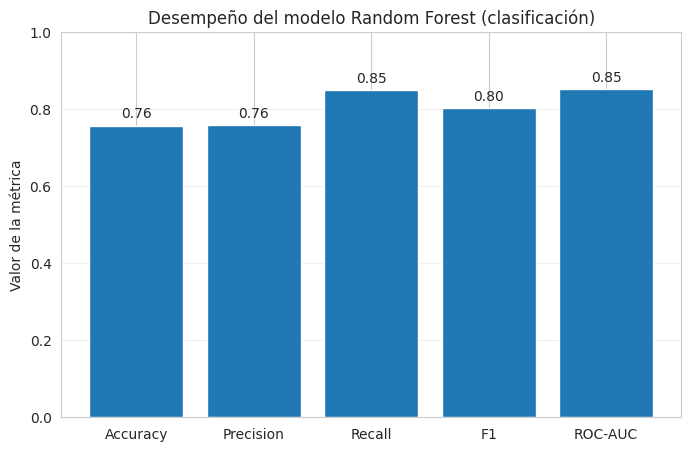

In [ ]:
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

metricas = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
valores = [acc, prec, rec, f1, auc]

plt.figure(figsize=(8,5))
plt.bar(metricas, valores)
plt.ylim(0, 1)
plt.ylabel("Valor de la métrica")
plt.title("Desempeño del modelo Random Forest (clasificación)")
plt.grid(axis="y", alpha=0.3)

# Mostrar valores sobre cada barra
for i, v in enumerate(valores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

plt.show()


In [ ]:
prec_loo = np.mean(precisiones)
rec_loo  = np.mean(recalls)
ndcg_loo = np.mean(ndcgs)

print("Precision@10 (LOO):", prec_loo)
print("Recall@10 (LOO):", rec_loo)
print("NDCG@10 (LOO):", ndcg_loo)


Precision@10 (LOO): 0.025108782251639393
Recall@10 (LOO): 0.25108782251639394
NDCG@10 (LOO): 0.15469353825441512


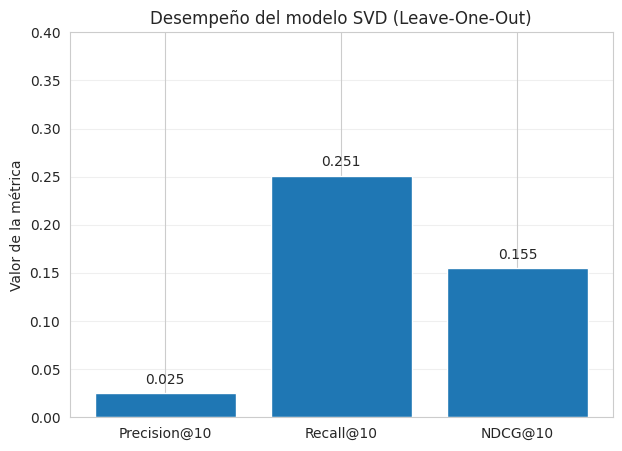

In [ ]:
import matplotlib.pyplot as plt

metricas = ["Precision@10", "Recall@10", "NDCG@10"]
valores = [prec_loo, rec_loo, ndcg_loo]

plt.figure(figsize=(7,5))
plt.bar(metricas, valores)
plt.ylim(0, 0.4)  # misma escala que ya usaste (honesto y comparable)
plt.ylabel("Valor de la métrica")
plt.title("Desempeño del modelo SVD (Leave-One-Out)")
plt.grid(axis='y', alpha=0.3)

# Mostrar valores sobre las barras
for i, v in enumerate(valores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

plt.show()


In [ ]:
# Métricas Random Forest
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1s = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Métricas SVD
prec10 = np.mean(precisiones)
rec10 = np.mean(recalls)
ndcg10 = np.mean(ndcgs)


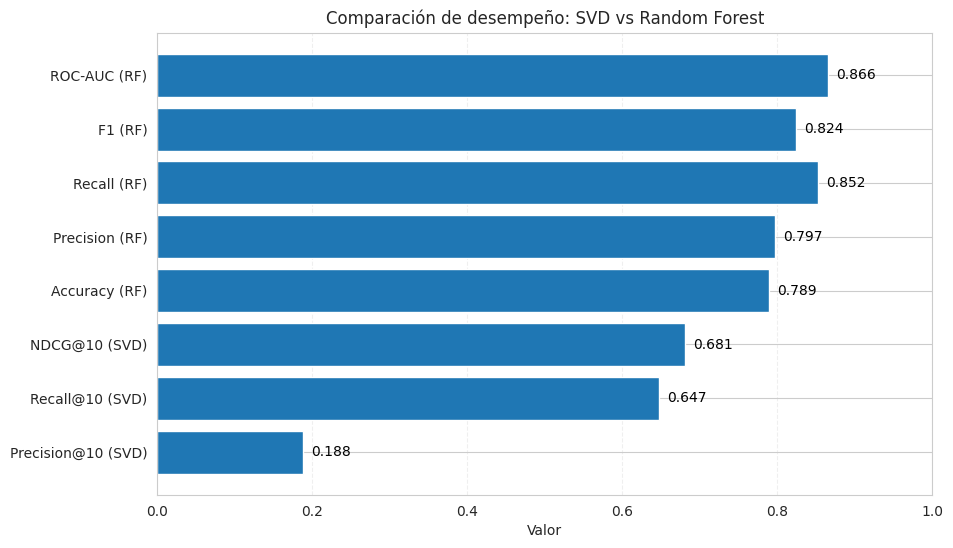

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    'Precision@10 (SVD)',
    'Recall@10 (SVD)',
    'NDCG@10 (SVD)',
    'Accuracy (RF)',
    'Precision (RF)',
    'Recall (RF)',
    'F1 (RF)',
    'ROC-AUC (RF)'
]

values = [
    prec10,
    rec10,
    ndcg10,
    acc,
    prec,
    rec,
    f1s,
    auc
]

plt.figure(figsize=(10,6))
bars = plt.barh(metrics, values)

plt.title("Comparación de desempeño: SVD vs Random Forest")
plt.xlim(0, 1)
plt.xlabel("Valor")
plt.grid(axis="x", linestyle="--", alpha=0.3)

# --- Añadir valores sobre las barras ---
for bar, value in zip(bars, values):
    plt.text(
        value + 0.01,                 # Posición horizontal (un poquito a la derecha)
        bar.get_y() + bar.get_height()/2,  # Centro vertical de la barra
        f"{value:.3f}",               # Formato del número
        va='center',
        fontsize=10,
        color='black'
    )

plt.show()


In [ ]:
# KNN

In [ ]:
# 1. Crear la matriz usuario–carrera (0/1 o nota normalizada)

user_item_knn = df_students_courses.pivot_table(
    index='INS_ID',
    columns='CAR_NOMBRE_CARRERA',
    values='NOTA_POSTULA',
    aggfunc='mean'
).fillna(0)


In [ ]:
# 2. Importar KNN y hacer matriz de similitud entre ÍTEMS

from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn_model.fit(user_item_knn.T)  # Transpuesta → carreras como vectores

# La métrica coseno mide el ángulo entre dos vectores, NO la magnitud.
# Dos carreras pueden haber sido tomadas por pocos estudiantes o muchos,
# pero si los mismos tipos de estudiantes las toman, el coseno será alto.

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
# 3. Función para recomendar carreras con KNN

def knn_recomendar_carreras(carrera, top_k=10):
    distancias, indices = knn_model.kneighbors(
        user_item_knn.T.loc[[carrera]],
        n_neighbors=top_k+1
    )

    similares = user_item_knn.T.index[indices.flatten()[1:]]  # excluir la misma carrera
    return similares


In [ ]:
# 4. Recomendación personalizada (para un estudiante)

def knn_recomendar_usuario(student_id, top_k=10):
    # Carreras reales del estudiante
    reales = user_item_knn.loc[student_id]
    reales = reales[reales > 0].index.tolist()

    recomendaciones = set()

    for carrera in reales:
        similares = knn_recomendar_carreras(carrera, top_k)
        recomendaciones.update(similares)

    # Quitar las que ya vio
    recomendaciones = [c for c in recomendaciones if c not in reales]

    return list(recomendaciones)[:top_k]


In [ ]:
# 1. Crear un texto descriptivo para cada carrera

df_content = df_students_courses[['CAR_NOMBRE_CARRERA', 'SUBAREA_NOMBRE',
                                  'MODALIDAD', 'JORNADA']].drop_duplicates()

df_content = df_content.reset_index(drop=True)

df_content['descripcion'] = (
    df_content['CAR_NOMBRE_CARRERA'] + " " +
    df_content['SUBAREA_NOMBRE'].fillna('') + " " +
    df_content['MODALIDAD'].fillna('') + " " +
    df_content['JORNADA'].fillna('')
)

print("Total de carreras únicas:", len(df_content))




Total de carreras únicas: 932


In [ ]:
# 2. Vectorizar las descripciones con TF-IDF usando stopwords en español

from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords en español (manual para compatibilidad)
spanish_stopwords = [
    "de","la","las","el","los","y","en","del","para","por","con","una","un",
    "al","se","que","su","a","o","u","es","son","lo","como","sus",
    "más","muy","este","esta","estos","estas"
]

vectorizer = TfidfVectorizer(stop_words=spanish_stopwords)
tfidf_matrix = vectorizer.fit_transform(df_content["descripcion"])

print("TF-IDF generado. Dimensiones:", tfidf_matrix.shape)




TF-IDF generado. Dimensiones: (932, 397)


In [ ]:
# 3. Aplicar KNN (cosine + brute)

from sklearn.neighbors import NearestNeighbors

knn_content = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn_content.fit(tfidf_matrix)

print("Modelo KNN de contenido entrenado.")



Modelo KNN de contenido entrenado.


In [ ]:
# 4. Función para recomendar carreras similares (por contenido)

# Obtener índice de carrera en df_content (robusto)

def get_carrera_index(carrera):
    rows = df_content.index[df_content['CAR_NOMBRE_CARRERA'] == carrera].tolist()
    if len(rows) == 0:
        return None
    return rows[0]  # Primera coincidencia

# Recomendación KNN por contenido
def recomendar_por_contenido(carrera, top_k=10):
    idx = get_carrera_index(carrera)
    if idx is None:
        return []  # Carrera no encontrada

    consulta = tfidf_matrix[idx]
    distancias, indices = knn_content.kneighbors(consulta, n_neighbors=top_k+1)

    similares = df_content.iloc[indices[0][1:]]['CAR_NOMBRE_CARRERA'].values
    return similares



In [ ]:
# 5. Recomendación personalizada por estudiante

def recomendar_usuario_contenido(student_id, top_k=10):
    # Carreras reales del estudiante
    reales = user_item_knn.loc[student_id]
    reales = reales[reales > 0].index.tolist()

    recomendaciones = set()

    for carrera in reales:
        similares = recomendar_por_contenido(carrera, top_k=10)
        recomendaciones.update(similares)

    # Quitar las carreras que el estudiante ya eligió
    recomendaciones = [c for c in recomendaciones if c not in reales]

    return recomendaciones[:top_k]



In [ ]:
# 6. Evaluación con Precision@10, Recall@10, NDCG@10

import numpy as np

def ndcg_at_k(r, k):
    r = np.asarray(r, dtype=float)[:k]
    if r.size == 0:
        return 0.0

    dcg = np.sum(r / np.log2(np.arange(2, r.size + 2)))
    ideal_r = np.sort(r)[::-1]
    idcg = np.sum(ideal_r / np.log2(np.arange(2, ideal_r.size + 2)))
    return dcg / idcg if idcg > 0 else 0.0



In [ ]:
# 7. Evaluación Content-KNN

from tqdm import tqdm

prec_cb, rec_cb, ndcg_cb = [], [], []

# Muestra del 2% — eficiente pero suficiente
muestra = int(len(user_item_knn) * 0.02)
estudiantes_muestra = random.sample(list(user_item_knn.index), muestra)

print(f"Evaluando con {muestra} estudiantes...")

for student in tqdm(estudiantes_muestra):
    true_items = list(user_item_knn.loc[student][user_item_knn.loc[student] > 0].index)
    pred_items = recomendar_usuario_contenido(student, top_k=10)

    prec_cb.append(precision_at_k(true_items, pred_items, 10))
    rec_cb.append(recall_at_k(true_items, pred_items, 10))
    ndcg_cb.append(ndcg_at_k(
        [1 if item in true_items else 0 for item in pred_items],
        10
    ))

print("\n📊 RESULTADOS DEL KNN BASADO EN CONTENIDO")
print("Precision@10:", np.mean(prec_cb))
print("Recall@10:", np.mean(rec_cb))
print("NDCG@10:", np.mean(ndcg_cb))


Evaluando con 4375 estudiantes...


100%|██████████| 4375/4375 [00:49<00:00, 88.30it/s] 


📊 RESULTADOS DEL KNN BASADO EN CONTENIDO
Precision@10: 0.0
Recall@10: 0.0
NDCG@10: 0.0


In [ ]:
# Métricas del KNN basado en contenido
knn_prec10 = np.mean(prec_cb)   # Precision@10
knn_rec10  = np.mean(rec_cb)    # Recall@10
knn_ndcg10 = np.mean(ndcg_cb)   # NDCG@10

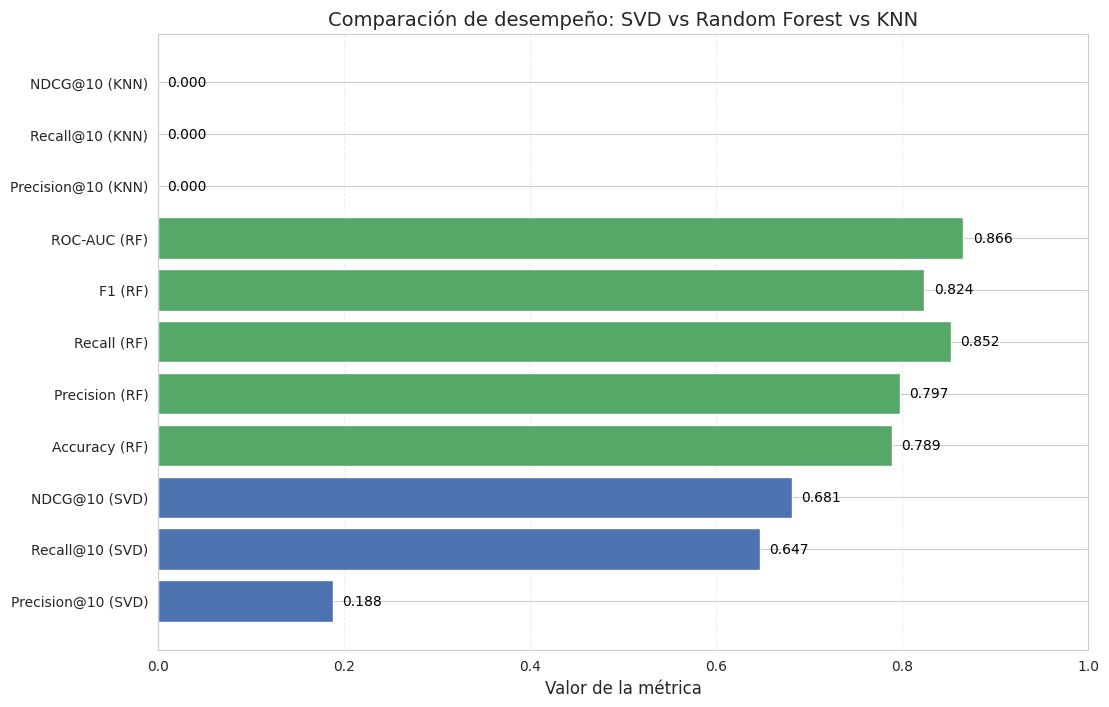

In [ ]:
import matplotlib.pyplot as plt

# --- MÉTRICAS A MOSTRAR ---
metrics = [
    'Precision@10 (SVD)',
    'Recall@10 (SVD)',
    'NDCG@10 (SVD)',
    'Accuracy (RF)',
    'Precision (RF)',
    'Recall (RF)',
    'F1 (RF)',
    'ROC-AUC (RF)',
    'Precision@10 (KNN)',
    'Recall@10 (KNN)',
    'NDCG@10 (KNN)'
]

# --- VALORES NUMÉRICOS ---
values = [
    prec10,
    rec10,
    ndcg10,
    acc,
    prec,
    rec,
    f1s,
    auc,
    knn_prec10,      # 0.0
    knn_rec10,       # 0.0
    knn_ndcg10       # 0.0
]

# --- ASIGNAR COLOR POR MODELO ---
colors = []
for m in metrics:
    if "(SVD)" in m:
        colors.append("#4C72B0")    # Azul SVD
    elif "(RF)" in m:
        colors.append("#55A868")    # Verde Random Forest
    else:
        colors.append("#C44E52")    # Rojo KNN


# --- GRÁFICO ---
plt.figure(figsize=(12,8))
bars = plt.barh(metrics, values, color=colors)

plt.title("Comparación de desempeño: SVD vs Random Forest vs KNN", fontsize=14)
plt.xlim(0, 1)
plt.xlabel("Valor de la métrica", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.3)


# --- Mostrar valores sobre las barras ---
for bar, value in zip(bars, values):
    plt.text(
        value + 0.01 if value < 0.90 else value - 0.10,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va='center',
        fontsize=10,
        color='black'
    )

plt.show()


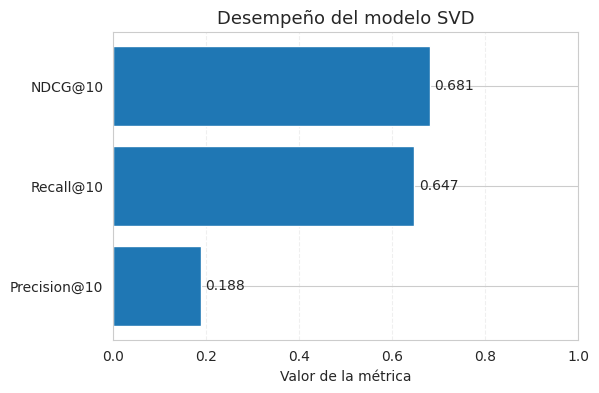

In [ ]:
import matplotlib.pyplot as plt

# --- MÉTRICAS SVD ---
metrics_svd = [
    'Precision@10',
    'Recall@10',
    'NDCG@10'
]

values_svd = [
    prec10,
    rec10,
    ndcg10
]

plt.figure(figsize=(6,4))
bars = plt.barh(metrics_svd, values_svd)

plt.title("Desempeño del modelo SVD", fontsize=13)
plt.xlim(0, 1)
plt.xlabel("Valor de la métrica")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, value in zip(bars, values_svd):
    plt.text(value + 0.01, bar.get_y() + bar.get_height()/2,
             f"{value:.3f}", va='center')

plt.show()


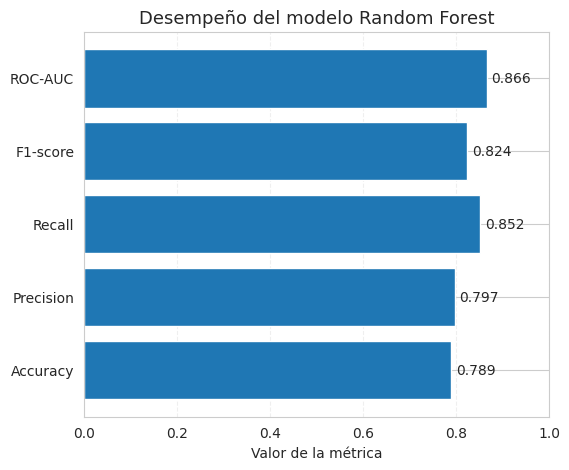

In [ ]:
# --- MÉTRICAS RANDOM FOREST ---
metrics_rf = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score',
    'ROC-AUC'
]

values_rf = [
    acc,
    prec,
    rec,
    f1s,
    auc
]

plt.figure(figsize=(6,5))
bars = plt.barh(metrics_rf, values_rf)

plt.title("Desempeño del modelo Random Forest", fontsize=13)
plt.xlim(0, 1)
plt.xlabel("Valor de la métrica")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, value in zip(bars, values_rf):
    plt.text(value + 0.01, bar.get_y() + bar.get_height()/2,
             f"{value:.3f}", va='center')

plt.show()


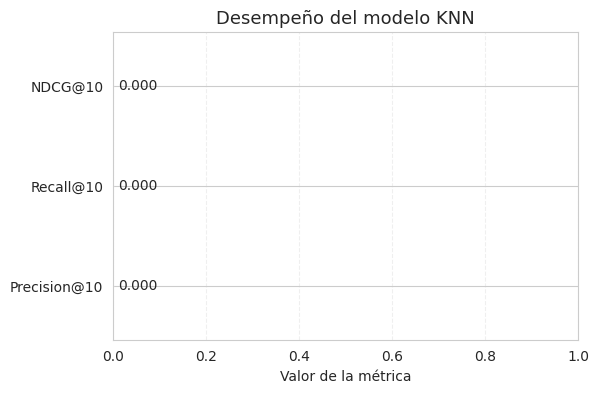

In [ ]:
# --- MÉTRICAS KNN ---
metrics_knn = [
    'Precision@10',
    'Recall@10',
    'NDCG@10'
]

values_knn = [
    knn_prec10,
    knn_rec10,
    knn_ndcg10
]

plt.figure(figsize=(6,4))
bars = plt.barh(metrics_knn, values_knn)

plt.title("Desempeño del modelo KNN", fontsize=13)
plt.xlim(0, 1)
plt.xlabel("Valor de la métrica")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, value in zip(bars, values_knn):
    plt.text(value + 0.01, bar.get_y() + bar.get_height()/2,
             f"{value:.3f}", va='center')

plt.show()
